In [60]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import STL

## Load Data

In [ ]:
KAGGLE_DATASETS = ["motor-temp", "wind-power", "store-sales", "antarctica-climate", "traffic"]

KAGGLE_PATHS = {
    "motor-temp": "/Users/hoyle/.cache/kagglehub/datasets/wkirgsn/electric-motor-temperature/versions/3",
    "wind-power": "/Users/hoyle/.cache/kagglehub/datasets/theforcecoder/wind-power-forecasting/versions/2",
    "store-sales": "/Users/hoyle/.cache/kagglehub/datasets/rohitsahoo/sales-forecasting/versions/2/",
    "antarctica-climate": "/Users/hoyle/.cache/kagglehub/datasets/sumanbera19/antarctica-climate-dataset-20062025-daily-data/versions/1",
    "traffic": os.getcwd(),
}

KAGGLE_FILE_NAMES = {
    "motor-temp": "measures_v2.csv",
    "wind-power": "Turbine_Data.csv",
    "store-sales": "train.csv",
    "antarctica-climate": "antarctica_climate_2006_2025.csv",
    "traffic": "traffic.csv",
}

SERIES_META = {
    "motor-temp": {"freq_seconds": 0.5, "domain": "industrial sensor"},
    "wind-power": {"freq_seconds": 600, "domain": "renewable energy"},
    "store-sales": {"freq_seconds": 86400, "domain": "retail"},
    "antarctica-climate": {"freq_seconds": 86400, "domain": "environmental"},
    "traffic": {"freq_seconds": 3600, "domain": "transportation"},
}

In [10]:
RAW = {}

def load_datasets():
    for i in KAGGLE_DATASETS:
        RAW[i] = pd.read_csv(os.path.join(KAGGLE_PATHS[i], KAGGLE_FILE_NAMES[i]))

In [ ]:
load_datasets()

,u_q,coolant,stator_winding,u_d,stator_tooth,motor_speed,i_d,i_q,pm,stator_yoke,ambient,torque,profile_id
0,-0.450682,18.805172,19.086670,-0.350055,18.293219,0.002866,0.004419,0.000328,24.554214,18.316547,19.850691,1.871008e-01,17
1,-0.325737,18.818571,19.092390,-0.305803,18.294807,0.000257,0.000606,-0.000785,24.538078,18.314955,19.850672,2.454175e-01,17
2,-0.440864,18.828770,19.089380,-0.372503,18.294094,0.002355,0.001290,0.000386,24.544693,18.326307,19.850657,1.766153e-01,17
3,-0.327026,18.835567,19.083031,-0.316199,18.292542,0.006105,0.000026,0.002046,24.554018,18.330833,19.850647,2.383027e-01,17
4,-0.471150,18.857033,19.082525,-0.332272,18.291428,0.003133,-0.064317,0.037184,24.565397,18.326662,19.850639,2.081967e-01,17
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1330811,-2.152128,30.721298,45.274497,0.791801,41.934347,0.000380,-2.000169,1.097528,62.147780,38.653720,23.989078,-8.116730e-60,71
1330812,-2.258684,30.721306,45.239017,0.778900,41.868923,0.002985,-2.000499,1.097569,62.142646,38.656328,23.970700,-5.815891e-60,71
1330813,-2.130312,30.721312,45.211576,0.804914,41.804819,0.002301,-1.999268,1.098765,62.138387,38.650923,23.977234,-4.167268e-60,71
1330814,-2.268498,30.721316,45.193508,0.763091,41.762220,0.005662,-2.000999,1.095696,62.133422,38.655686,24.001421,-2.985978e-60,71


## Target Evalutation

In [13]:
for name, df in RAW.items():
    print(f"\n=== {name} ===")
    print("shape:", df.shape)
    print("columns:", list(df.columns))
    print("missing values:\n", df.isna().sum()[df.isna().sum() > 0])
    print(df.head(3))


=== motor-temp ===
shape: (1330816, 13)
columns: ['u_q', 'coolant', 'stator_winding', 'u_d', 'stator_tooth', 'motor_speed', 'i_d', 'i_q', 'pm', 'stator_yoke', 'ambient', 'torque', 'profile_id']
missing values:
 Series([], dtype: int64)
        u_q    coolant  stator_winding       u_d  stator_tooth  motor_speed  \
0 -0.450682  18.805172        19.08667 -0.350055     18.293219     0.002866   
1 -0.325737  18.818571        19.09239 -0.305803     18.294807     0.000257   
2 -0.440864  18.828770        19.08938 -0.372503     18.294094     0.002355   

        i_d       i_q         pm  stator_yoke    ambient    torque  profile_id  
0  0.004419  0.000328  24.554214    18.316547  19.850691  0.187101          17  
1  0.000606 -0.000785  24.538078    18.314955  19.850672  0.245417          17  
2  0.001290  0.000386  24.544693    18.326307  19.850657  0.176615          17  

=== wind-power ===
shape: (118224, 22)
columns: ['Unnamed: 0', 'ActivePower', 'AmbientTemperatue', 'BearingShaftTemperatu

In [ ]:
SERIES = {}

# ---------- motor-temp ----------
df = RAW["motor-temp"]
print("profile_id counts:\n", df["profile_id"].value_counts().head())

# pick the longest profile_id as your continuous run
chosen_profile = df["profile_id"].value_counts().idxmax()
sub = df[df["profile_id"] == chosen_profile].reset_index(drop=True)
target_col = "pm"  # permanent magnet temperature — confirm this is your intended target
SERIES["motor-temp"] = sub[target_col]
print(f"\nmotor-temp: using profile_id={chosen_profile}, target='{target_col}', n={len(sub)}")
# NOTE: no real timestamps exist — treat row index as time steps.
# Confirm the actual sampling rate (commonly cited as 2 Hz for this dataset) from the
# dataset documentation before stating it in your report.

# ---------- wind-power ----------
df = RAW["wind-power"].rename(columns={"Unnamed: 0": "timestamp"})
df["timestamp"] = pd.to_datetime(df["timestamp"])
df = df.set_index("timestamp").sort_index()

target_col = "ActivePower"
print("\nwind-power missing at start:")
print(df[target_col].isna().cumsum().eq(range(1, len(df) + 1)).sum(), "leading NaNs")  # rough check

# trim leading all-NaN block, then check remaining gap sizes before deciding imputation
first_valid = df[target_col].first_valid_index()
trimmed = df.loc[first_valid:]
print(f"wind-power: trimmed to {len(trimmed)} rows starting {first_valid}")
print("remaining missing after trim:", trimmed[target_col].isna().sum())
SERIES["wind-power"] = trimmed[target_col]
# NOTE: still likely has internal gaps (maintenance/downtime) — decide and justify
# your imputation strategy (short-gap interpolation vs. dropping long-gap segments)
# once you see the gap-size distribution.

# ---------- store-sales ----------
df = RAW["store-sales"].copy()
# verify date format explicitly rather than assuming
df["Order Date"] = pd.to_datetime(df["Order Date"], dayfirst=True)  # confirm this against a few known rows
daily_sales = df.groupby("Order Date")["Sales"].sum().sort_index()
SERIES["store-sales"] = daily_sales
print(f"\nstore-sales: aggregated to {len(daily_sales)} daily points, "
      f"{daily_sales.index.min()} to {daily_sales.index.max()}")
# NOTE: daily series will likely have gaps (no orders some days) — decide whether
# to fill with 0 (no sales that day) or resample/interpolate. Filling with 0 is
# usually the more defensible choice for sales counts, since "no orders" is real information.

# ---------- antarctica-climate ----------
df = RAW["antarctica-climate"].copy()
print("\nantarctica locations:", df["location"].unique())

chosen_location = df["location"].unique()[0]  # pick deliberately, don't just take [0] blindly
sub = df[df["location"] == chosen_location].copy()
sub["date"] = pd.to_datetime(sub["date"])
sub = sub.set_index("date").sort_index()
SERIES["antarctica-climate"] = sub["temperature_2m_mean"]
print(f"antarctica-climate: using location='{chosen_location}', n={len(sub)}")

# ---------- traffic ----------
df = RAW["traffic"].copy()
df["date"] = pd.to_datetime(df["date"])
df = df.set_index("date").sort_index()
SERIES["traffic"] = df["OT"]  # 'OT' is the conventional target column in this benchmark — verify
print(f"\ntraffic: using column 'OT', n={len(df)}")

# ---------- summary ----------
print("\n=== SERIES summary ===")
for name, s in SERIES.items():
    print(f"{name}: n={len(s)}, dtype={s.dtype}, nulls={s.isna().sum()}")

profile_id counts:
 profile_id
20    43971
6     40388
65    40094
18    37732
66    36476
Name: count, dtype: int64

motor-temp: using profile_id=20, target='pm', n=43971

wind-power missing at start:
144 leading NaNs
wind-power: trimmed to 118080 rows starting 2018-01-01 00:00:00+00:00
remaining missing after trim: 23330

store-sales: aggregated to 1230 daily points, 2015-01-03 00:00:00 to 2018-12-30 00:00:00

antarctica locations: <StringArray>
['Antarctic_Peninsula',     'East_Antarctica',             'McMurdo',
          'South_Pole',     'West_Antarctica']
Length: 5, dtype: str
antarctica-climate: using location='Antarctic_Peninsula', n=7305

traffic: using column 'OT', n=17544

=== SERIES summary ===
motor-temp: n=43971, dtype=float64, nulls=0
wind-power: n=118080, dtype=float64, nulls=23330
store-sales: n=1230, dtype=float64, nulls=0
antarctica-climate: n=7305, dtype=float64, nulls=0
traffic: n=17544, dtype=float64, nulls=0


In [16]:
# ---------- wind-power: inspect gap structure before deciding imputation ----------
s = SERIES["wind-power"]
is_na = s.isna()

# find contiguous missing-value runs
gap_groups = (is_na != is_na.shift()).cumsum()[is_na]
gap_sizes = gap_groups.value_counts().sort_values(ascending=False)

print("wind-power missing-run summary:")
print(f"  number of separate gaps: {len(gap_sizes)}")
print(f"  largest gaps (in rows, 10-min sampling so /6 = hours):")
print((gap_sizes.head(10) / 6).round(1), "hours")
print(f"  gaps of 1-3 rows (short): {(gap_sizes <= 3).sum()}")
print(f"  gaps > 24 hours (144 rows): {(gap_sizes > 144).sum()}")

wind-power missing-run summary:
  number of separate gaps: 1666
  largest gaps (in rows, 10-min sampling so /6 = hours):
ActivePower
814     172.3
256     170.0
1120    168.2
556     168.0
1296    168.0
1458    168.0
3030    132.0
644     120.0
1010    118.3
2590     64.3
Name: count, dtype: float64 hours
  gaps of 1-3 rows (short): 1258
  gaps > 24 hours (144 rows): 25


In [ ]:
# Store-sales: make the implicit gaps explicit
s = SERIES["store-sales"]
full_range = pd.date_range(s.index.min(), s.index.max(), freq="D")
s_reindexed = s.reindex(full_range, fill_value=0.0)
s_reindexed.index.name = "date"

print(f"store-sales: {len(s)} → {len(s_reindexed)} after reindexing to daily frequency")
print(f"days with zero sales: {(s_reindexed == 0).sum()}")

SERIES["store-sales"] = s_reindexed

store-sales: 1230 → 1458 after reindexing to daily frequency
days with zero sales: 228


In [18]:
for name, s in SERIES.items():
    if isinstance(s.index, pd.DatetimeIndex):
        freq = pd.infer_freq(s.index)
        print(f"{name}: inferred freq = {freq}, index monotonic = {s.index.is_monotonic_increasing}, duplicates = {s.index.duplicated().sum()}")
    else:
        print(f"{name}: non-datetime index (row-based), length = {len(s)}")

motor-temp: non-datetime index (row-based), length = 43971
wind-power: inferred freq = 10min, index monotonic = True, duplicates = 0
store-sales: inferred freq = D, index monotonic = True, duplicates = 0
antarctica-climate: inferred freq = D, index monotonic = True, duplicates = 0
traffic: inferred freq = h, index monotonic = True, duplicates = 0


In [19]:
# ---------- wind-power: interpolate short gaps, then isolate longest clean run ----------
s = SERIES["wind-power"]

# interpolate only short gaps (limit=3 rows ~ 30 min); leave long gaps as NaN
s_interp = s.interpolate(method="linear", limit=3)

print("remaining missing after short-gap interpolation:", s_interp.isna().sum())

# find contiguous non-null runs and pick the longest
is_valid = s_interp.notna()
run_id = (is_valid != is_valid.shift()).cumsum()
run_lengths = s_interp[is_valid].groupby(run_id[is_valid]).size()
longest_run_id = run_lengths.idxmax()

clean_series = s_interp[(run_id == longest_run_id) & is_valid]

print(f"longest clean run: {len(clean_series)} rows "
      f"({clean_series.index.min()} to {clean_series.index.max()}, "
      f"~{len(clean_series)/6/24:.0f} days)")

SERIES["wind-power"] = clean_series

remaining missing after short-gap interpolation: 20501
longest clean run: 5039 rows (2019-03-13 07:20:00+00:00 to 2019-04-17 07:00:00+00:00, ~35 days)


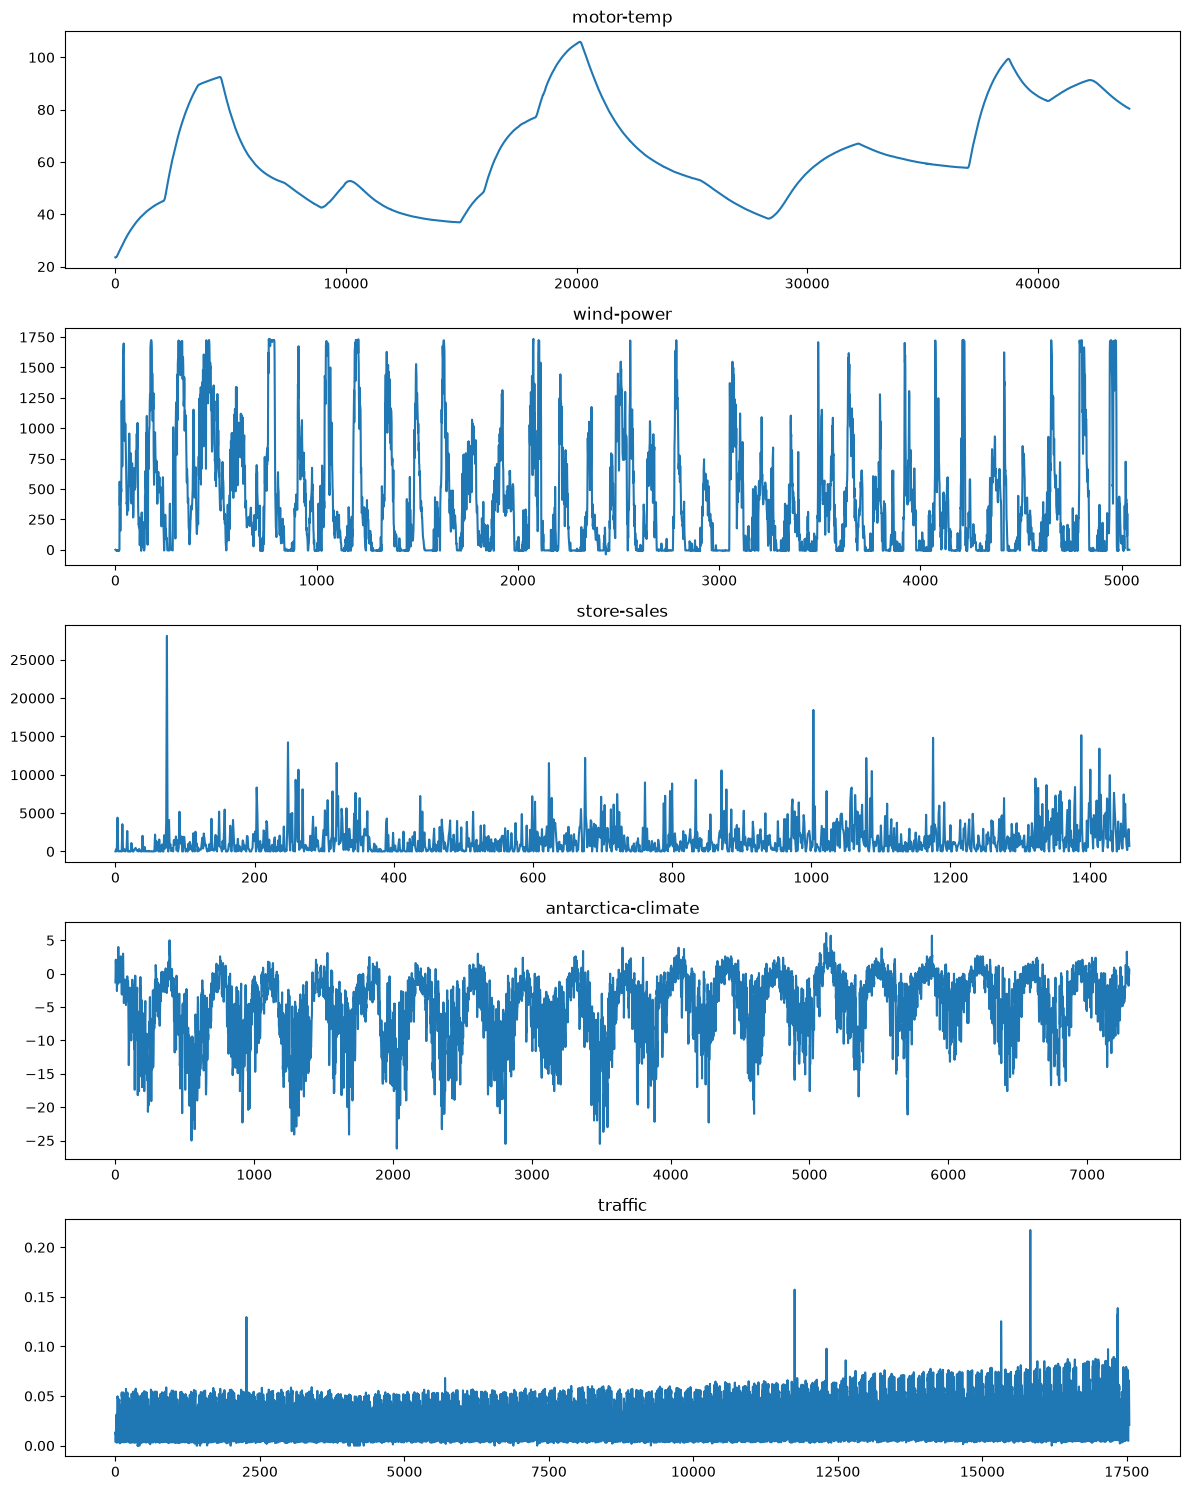

In [ ]:
fig, axes = plt.subplots(len(SERIES), 1, figsize=(12, 3 * len(SERIES)))
for ax, (name, s) in zip(axes, SERIES.items()):
    ax.plot(s.values)
    ax.set_title(name)
plt.tight_layout()
plt.show()

## Stationarity Test

In [ ]:
def test_stationarity(name, series, verbose=True):
    s = series.dropna()

    adf_stat, adf_p, *_ = adfuller(s, autolag="AIC")
    # KPSS has a max lag warning for large series; regression="c" tests stationarity around a constant
    kpss_stat, kpss_p, *_ = kpss(s, regression="c", nlags="auto")

    adf_stationary = adf_p < 0.05      # ADF null = non-stationary; reject → stationary
    kpss_stationary = kpss_p >= 0.05   # KPSS null = stationary; fail to reject → stationary

    result = {
        "dataset": name,
        "adf_stat": adf_stat, "adf_p": adf_p, "adf_says_stationary": adf_stationary,
        "kpss_stat": kpss_stat, "kpss_p": kpss_p, "kpss_says_stationary": kpss_stationary,
    }

    if verbose:
        print(f"\n=== {name} ===")
        print(f"ADF:  stat={adf_stat:.4f}, p={adf_p:.4f} -> {'stationary' if adf_stationary else 'NON-stationary'}")
        print(f"KPSS: stat={kpss_stat:.4f}, p={kpss_p:.4f} -> {'stationary' if kpss_stationary else 'NON-stationary'}")
        if adf_stationary != kpss_stationary:
            print("  ** ADF and KPSS disagree — inspect more closely, note this explicitly in report **")

    return result

STATIONARITY_RESULTS = {}
for name, s in SERIES.items():
    STATIONARITY_RESULTS[name] = test_stationarity(name, s)

import pandas as pd
stationarity_df = pd.DataFrame(STATIONARITY_RESULTS).T
print("\n=== Summary ===")
print(stationarity_df)

/var/folders/p2/hf8jpcl93xg8h2055603h_940000gn/T/ipykernel_57870/3522151822.py:6: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  adf_stat, adf_p, *_ = adfuller(s, autolag="AIC")
/var/folders/p2/hf8jpcl93xg8h2055603h_940000gn/T/ipykernel_57870/3522151822.py:8: InterpolationWarning: The test statistic is outside of the range of p-values available in the look-up table. The actual p-value is smaller than the p-value returned.
  kpss_stat, kpss_p, *_ = kpss(s, regression="c", nlags="auto")
/var/folders/p2/hf8jpcl93xg8h2055603h_940000gn/T/ipykernel_57870/3522151822.py:8: FutureWarning: kpss currently returns a plain tuple whose length and layout depends on the store argument (and which


=== motor-temp ===
ADF:  stat=-4.0893, p=0.0010 -> stationary
KPSS: stat=6.2089, p=0.0100 -> NON-stationary
  ** ADF and KPSS disagree — inspect more closely, note this explicitly in report **

=== wind-power ===
ADF:  stat=-10.8250, p=0.0000 -> stationary
KPSS: stat=1.1243, p=0.0100 -> NON-stationary
  ** ADF and KPSS disagree — inspect more closely, note this explicitly in report **

=== store-sales ===
ADF:  stat=-4.9266, p=0.0000 -> stationary
KPSS: stat=2.0535, p=0.0100 -> NON-stationary
  ** ADF and KPSS disagree — inspect more closely, note this explicitly in report **


/var/folders/p2/hf8jpcl93xg8h2055603h_940000gn/T/ipykernel_57870/3522151822.py:6: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  adf_stat, adf_p, *_ = adfuller(s, autolag="AIC")
/var/folders/p2/hf8jpcl93xg8h2055603h_940000gn/T/ipykernel_57870/3522151822.py:8: InterpolationWarning: The test statistic is outside of the range of p-values available in the look-up table. The actual p-value is smaller than the p-value returned.
  kpss_stat, kpss_p, *_ = kpss(s, regression="c", nlags="auto")
/var/folders/p2/hf8jpcl93xg8h2055603h_940000gn/T/ipykernel_57870/3522151822.py:8: FutureWarning: kpss currently returns a plain tuple whose length and layout depends on the store argument (and which


=== antarctica-climate ===
ADF:  stat=-5.8885, p=0.0000 -> stationary
KPSS: stat=2.0456, p=0.0100 -> NON-stationary
  ** ADF and KPSS disagree — inspect more closely, note this explicitly in report **

=== traffic ===
ADF:  stat=-11.5396, p=0.0000 -> stationary
KPSS: stat=14.6012, p=0.0100 -> NON-stationary
  ** ADF and KPSS disagree — inspect more closely, note this explicitly in report **

=== Summary ===
                               dataset   adf_stat     adf_p  \
motor-temp                  motor-temp  -4.089319  0.001009   
wind-power                  wind-power -10.824969       0.0   
store-sales                store-sales  -4.926583  0.000031   
antarctica-climate  antarctica-climate  -5.888458       0.0   
traffic                        traffic -11.539611       0.0   

                   adf_says_stationary  kpss_stat kpss_p kpss_says_stationary  
motor-temp                        True   6.208945   0.01                False  
wind-power                        True   1.124278

/var/folders/p2/hf8jpcl93xg8h2055603h_940000gn/T/ipykernel_57870/3522151822.py:6: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  adf_stat, adf_p, *_ = adfuller(s, autolag="AIC")
/var/folders/p2/hf8jpcl93xg8h2055603h_940000gn/T/ipykernel_57870/3522151822.py:8: InterpolationWarning: The test statistic is outside of the range of p-values available in the look-up table. The actual p-value is smaller than the p-value returned.
  kpss_stat, kpss_p, *_ = kpss(s, regression="c", nlags="auto")
/var/folders/p2/hf8jpcl93xg8h2055603h_940000gn/T/ipykernel_57870/3522151822.py:8: FutureWarning: kpss currently returns a plain tuple whose length and layout depends on the store argument (and which

In [61]:
def test_stationarity_v2(name, series, verbose=True):
    s = series.dropna()

    adf_stat, adf_p, *_ = adfuller(s, autolag="AIC")
    kpss_c_stat, kpss_c_p, *_ = kpss(s, regression="c", nlags="auto")
    kpss_ct_stat, kpss_ct_p, *_ = kpss(s, regression="ct", nlags="auto")  # trend-stationary test

    result = {
        "dataset": name,
        "adf_p": adf_p,
        "kpss_const_p": kpss_c_p,
        "kpss_trend_p": kpss_ct_p,
    }
    if verbose:
        print(f"\n=== {name} ===")
        print(f"ADF p={adf_p:.4f} -> {'no unit root' if adf_p < 0.05 else 'unit root present'}")
        print(f"KPSS (const) p={kpss_c_p:.4f} -> {'stationary' if kpss_c_p >= 0.05 else 'non-stationary around constant'}")
        print(f"KPSS (trend) p={kpss_ct_p:.4f} -> {'trend-stationary' if kpss_ct_p >= 0.05 else 'non-stationary even around trend'}")
    return result

print("WITHOUT DIFFERENCING")
for name, s in SERIES.items():
    test_stationarity_v2(name, s)

WITHOUT DIFFERENCING


/var/folders/p2/hf8jpcl93xg8h2055603h_940000gn/T/ipykernel_57870/2282018704.py:4: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  adf_stat, adf_p, *_ = adfuller(s, autolag="AIC")
/var/folders/p2/hf8jpcl93xg8h2055603h_940000gn/T/ipykernel_57870/2282018704.py:5: InterpolationWarning: The test statistic is outside of the range of p-values available in the look-up table. The actual p-value is smaller than the p-value returned.
  kpss_c_stat, kpss_c_p, *_ = kpss(s, regression="c", nlags="auto")
/var/folders/p2/hf8jpcl93xg8h2055603h_940000gn/T/ipykernel_57870/2282018704.py:5: FutureWarning: kpss currently returns a plain tuple whose length and layout depends on the store argument (and w


=== motor-temp ===
ADF p=0.0010 -> no unit root
KPSS (const) p=0.0100 -> non-stationary around constant
KPSS (trend) p=0.0100 -> non-stationary even around trend

=== wind-power ===
ADF p=0.0000 -> no unit root
KPSS (const) p=0.0100 -> non-stationary around constant
KPSS (trend) p=0.0738 -> trend-stationary

=== store-sales ===
ADF p=0.0000 -> no unit root
KPSS (const) p=0.0100 -> non-stationary around constant
KPSS (trend) p=0.0331 -> non-stationary even around trend


/var/folders/p2/hf8jpcl93xg8h2055603h_940000gn/T/ipykernel_57870/2282018704.py:4: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  adf_stat, adf_p, *_ = adfuller(s, autolag="AIC")
/var/folders/p2/hf8jpcl93xg8h2055603h_940000gn/T/ipykernel_57870/2282018704.py:5: InterpolationWarning: The test statistic is outside of the range of p-values available in the look-up table. The actual p-value is smaller than the p-value returned.
  kpss_c_stat, kpss_c_p, *_ = kpss(s, regression="c", nlags="auto")
/var/folders/p2/hf8jpcl93xg8h2055603h_940000gn/T/ipykernel_57870/2282018704.py:5: FutureWarning: kpss currently returns a plain tuple whose length and layout depends on the store argument (and w


=== antarctica-climate ===
ADF p=0.0000 -> no unit root
KPSS (const) p=0.0100 -> non-stationary around constant
KPSS (trend) p=0.1000 -> trend-stationary

=== traffic ===
ADF p=0.0000 -> no unit root
KPSS (const) p=0.0100 -> non-stationary around constant
KPSS (trend) p=0.0100 -> non-stationary even around trend


/var/folders/p2/hf8jpcl93xg8h2055603h_940000gn/T/ipykernel_57870/2282018704.py:4: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  adf_stat, adf_p, *_ = adfuller(s, autolag="AIC")
/var/folders/p2/hf8jpcl93xg8h2055603h_940000gn/T/ipykernel_57870/2282018704.py:5: InterpolationWarning: The test statistic is outside of the range of p-values available in the look-up table. The actual p-value is smaller than the p-value returned.
  kpss_c_stat, kpss_c_p, *_ = kpss(s, regression="c", nlags="auto")
/var/folders/p2/hf8jpcl93xg8h2055603h_940000gn/T/ipykernel_57870/2282018704.py:5: FutureWarning: kpss currently returns a plain tuple whose length and layout depends on the store argument (and w

In [23]:
DIFFERENCED = {}
for name, s in SERIES.items():
    diff = s.diff().dropna()
    DIFFERENCED[name] = diff
    print(f"\n=== {name} (differenced) ===")
    test_stationarity_v2(name, diff)


=== motor-temp (differenced) ===


/var/folders/p2/hf8jpcl93xg8h2055603h_940000gn/T/ipykernel_57870/3492187451.py:4: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  adf_stat, adf_p, *_ = adfuller(s, autolag="AIC")
/var/folders/p2/hf8jpcl93xg8h2055603h_940000gn/T/ipykernel_57870/3492187451.py:5: FutureWarning: kpss currently returns a plain tuple whose length and layout depends on the store argument (and which silently drops `lags` when store=True). In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning a KPSSResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  kpss_c_stat, kpss_c_p, *_ = kp


=== motor-temp ===
ADF p=0.0047 -> no unit root
KPSS (const) p=0.0193 -> non-stationary around constant
KPSS (trend) p=0.0100 -> non-stationary even around trend

=== wind-power (differenced) ===

=== wind-power ===
ADF p=0.0000 -> no unit root
KPSS (const) p=0.1000 -> stationary
KPSS (trend) p=0.1000 -> trend-stationary

=== store-sales (differenced) ===

=== store-sales ===
ADF p=0.0000 -> no unit root
KPSS (const) p=0.1000 -> stationary
KPSS (trend) p=0.1000 -> trend-stationary

=== antarctica-climate (differenced) ===


/var/folders/p2/hf8jpcl93xg8h2055603h_940000gn/T/ipykernel_57870/3492187451.py:4: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  adf_stat, adf_p, *_ = adfuller(s, autolag="AIC")
/var/folders/p2/hf8jpcl93xg8h2055603h_940000gn/T/ipykernel_57870/3492187451.py:5: InterpolationWarning: The test statistic is outside of the range of p-values available in the look-up table. The actual p-value is greater than the p-value returned.
  kpss_c_stat, kpss_c_p, *_ = kpss(s, regression="c", nlags="auto")
/var/folders/p2/hf8jpcl93xg8h2055603h_940000gn/T/ipykernel_57870/3492187451.py:5: FutureWarning: kpss currently returns a plain tuple whose length and layout depends on the store argument (and w


=== antarctica-climate ===
ADF p=0.0000 -> no unit root
KPSS (const) p=0.1000 -> stationary
KPSS (trend) p=0.1000 -> trend-stationary

=== traffic (differenced) ===

=== traffic ===
ADF p=0.0000 -> no unit root
KPSS (const) p=0.1000 -> stationary
KPSS (trend) p=0.1000 -> trend-stationary


/var/folders/p2/hf8jpcl93xg8h2055603h_940000gn/T/ipykernel_57870/3492187451.py:4: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  adf_stat, adf_p, *_ = adfuller(s, autolag="AIC")
/var/folders/p2/hf8jpcl93xg8h2055603h_940000gn/T/ipykernel_57870/3492187451.py:5: InterpolationWarning: The test statistic is outside of the range of p-values available in the look-up table. The actual p-value is greater than the p-value returned.
  kpss_c_stat, kpss_c_p, *_ = kpss(s, regression="c", nlags="auto")
/var/folders/p2/hf8jpcl93xg8h2055603h_940000gn/T/ipykernel_57870/3492187451.py:5: FutureWarning: kpss currently returns a plain tuple whose length and layout depends on the store argument (and w

### Testing Motor-Temp

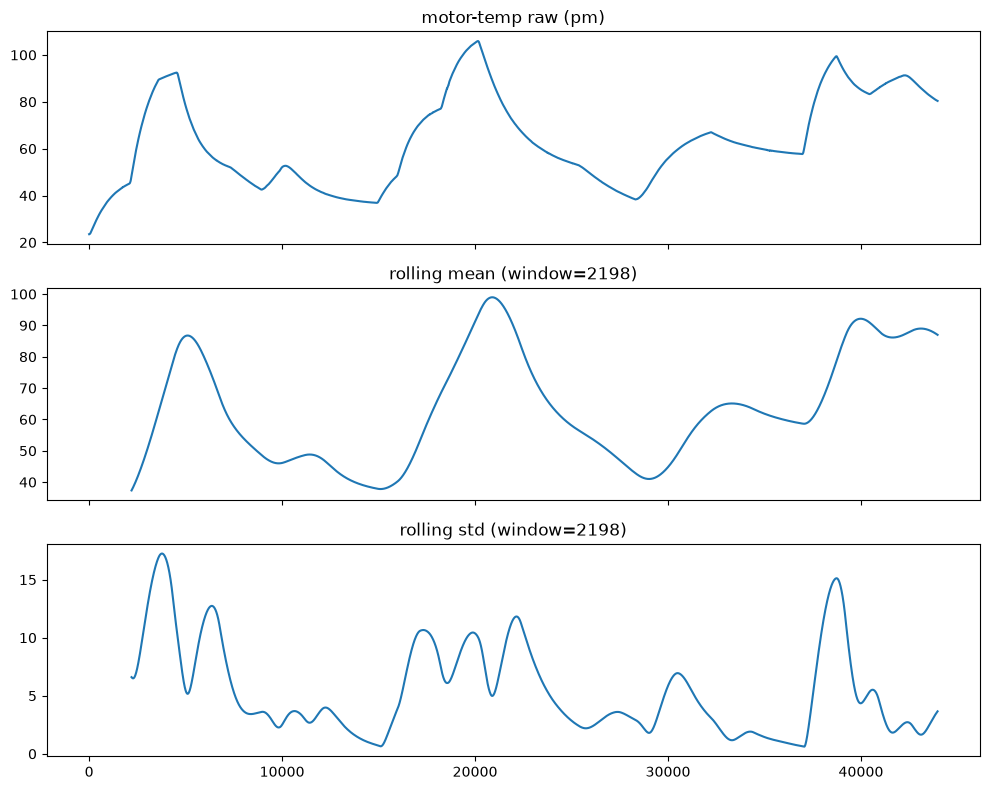

In [24]:
s = SERIES["motor-temp"]
window = len(s) // 20  # ~5% window

rolling_mean = s.rolling(window).mean()
rolling_std = s.rolling(window).std()

fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)
axes[0].plot(s.values); axes[0].set_title("motor-temp raw (pm)")
axes[1].plot(rolling_mean.values); axes[1].set_title(f"rolling mean (window={window})")
axes[2].plot(rolling_std.values); axes[2].set_title(f"rolling std (window={window})")
plt.tight_layout()
plt.show()

## EDA - Target

In [26]:
def run_eda(name, series, seasonal_period=None):
    s = series.dropna()
    print(f"\n{'='*50}\n{name}\n{'='*50}")

    # ---- summary stats ----
    print(s.describe())
    print(f"skew: {s.skew():.3f}, kurtosis: {s.kurt():.3f}")

    # ---- outlier check (simple z-score / IQR flag) ----
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    outliers = s[(s < q1 - 3*iqr) | (s > q3 + 3*iqr)]
    print(f"extreme outliers (3x IQR): {len(outliers)} ({100*len(outliers)/len(s):.2f}%)")

    # ---- plots: raw series, distribution, ACF, PACF ----
    fig, axes = plt.subplots(2, 2, figsize=(13, 7))
    axes[0,0].plot(s.values, linewidth=0.7)
    axes[0,0].set_title(f"{name} — raw series")

    axes[0,1].hist(s.values, bins=50)
    axes[0,1].set_title("distribution")

    plot_acf(s, ax=axes[1,0], lags=min(50, len(s)//4))
    axes[1,0].set_title("ACF")

    plot_pacf(s, ax=axes[1,1], lags=min(50, len(s)//4), method="ywm")
    axes[1,1].set_title("PACF")

    plt.tight_layout()
    plt.show()

    # ---- seasonal decomposition, if a period is known/plausible ----
    if seasonal_period and len(s) > 2 * seasonal_period:
        stl = STL(s, period=seasonal_period, robust=True).fit()
        fig, axes = plt.subplots(4, 1, figsize=(11, 8), sharex=True)
        axes[0].plot(s.values); axes[0].set_title("observed")
        axes[1].plot(stl.trend); axes[1].set_title("trend")
        axes[2].plot(stl.seasonal); axes[2].set_title("seasonal")
        axes[3].plot(stl.resid); axes[3].set_title("residual")
        plt.tight_layout()
        plt.show()

        # quick strength-of-seasonality / trend metrics (common in TS literature)
        var_resid = stl.resid.var()
        strength_trend = max(0, 1 - var_resid / (stl.trend + stl.resid).var())
        strength_seasonal = max(0, 1 - var_resid / (stl.seasonal + stl.resid).var())
        print(f"trend strength: {strength_trend:.3f}, seasonal strength: {strength_seasonal:.3f}")

    return {
        "n": len(s), "mean": s.mean(), "std": s.std(),
        "skew": s.skew(), "kurtosis": s.kurt(),
        "n_outliers": len(outliers),
    }


motor-temp
count    43971.000000
mean        63.065807
std         19.109689
min         23.534149
25%         46.772129
50%         59.730797
75%         80.859711
max        105.948723
Name: pm, dtype: float64
skew: 0.376, kurtosis: -0.942
extreme outliers (3x IQR): 0 (0.00%)


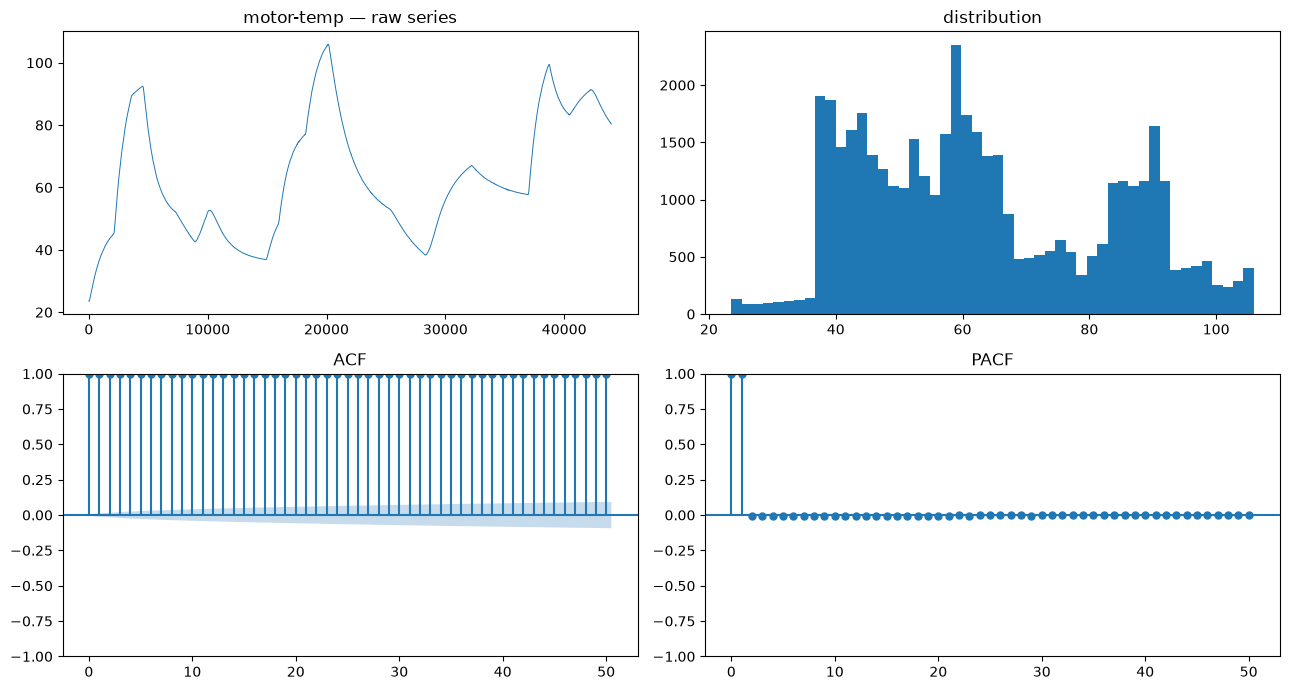


wind-power
count    5039.000000
mean      386.630523
std       458.543314
min       -38.312299
25%        -1.724580
50%       216.728900
75%       608.443747
max      1735.390000
Name: ActivePower, dtype: float64
skew: 1.294, kurtosis: 0.880
extreme outliers (3x IQR): 0 (0.00%)


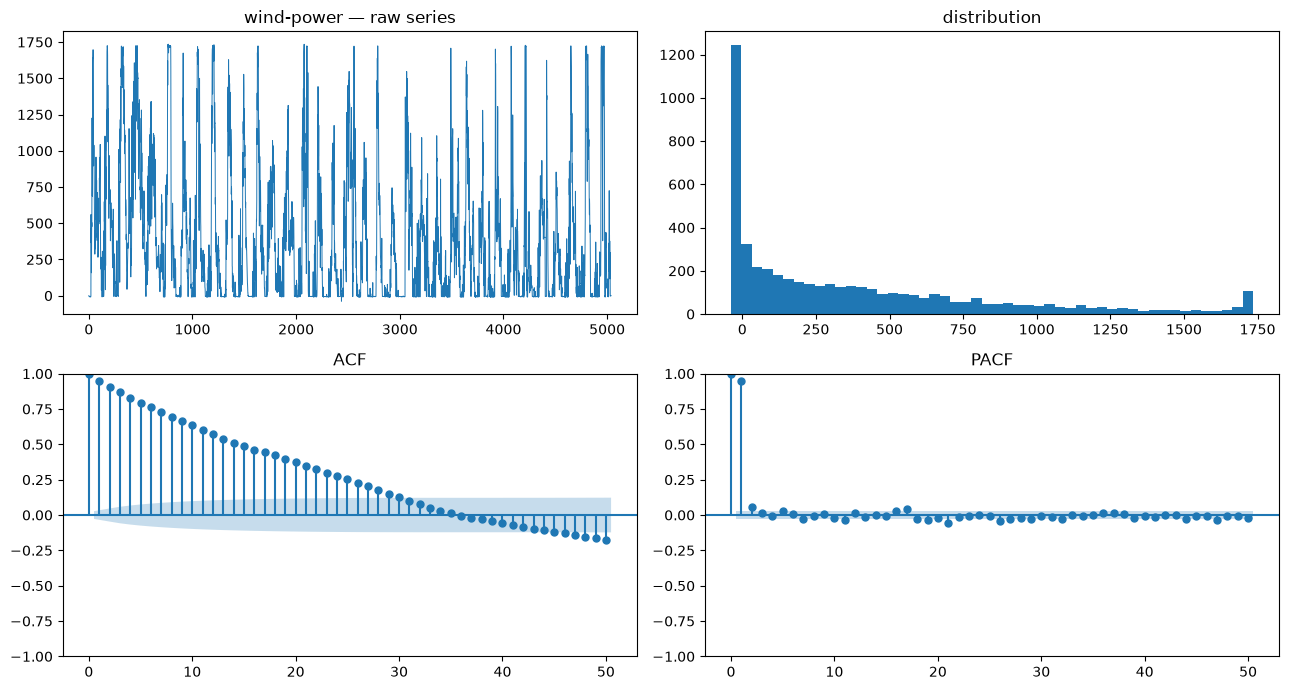

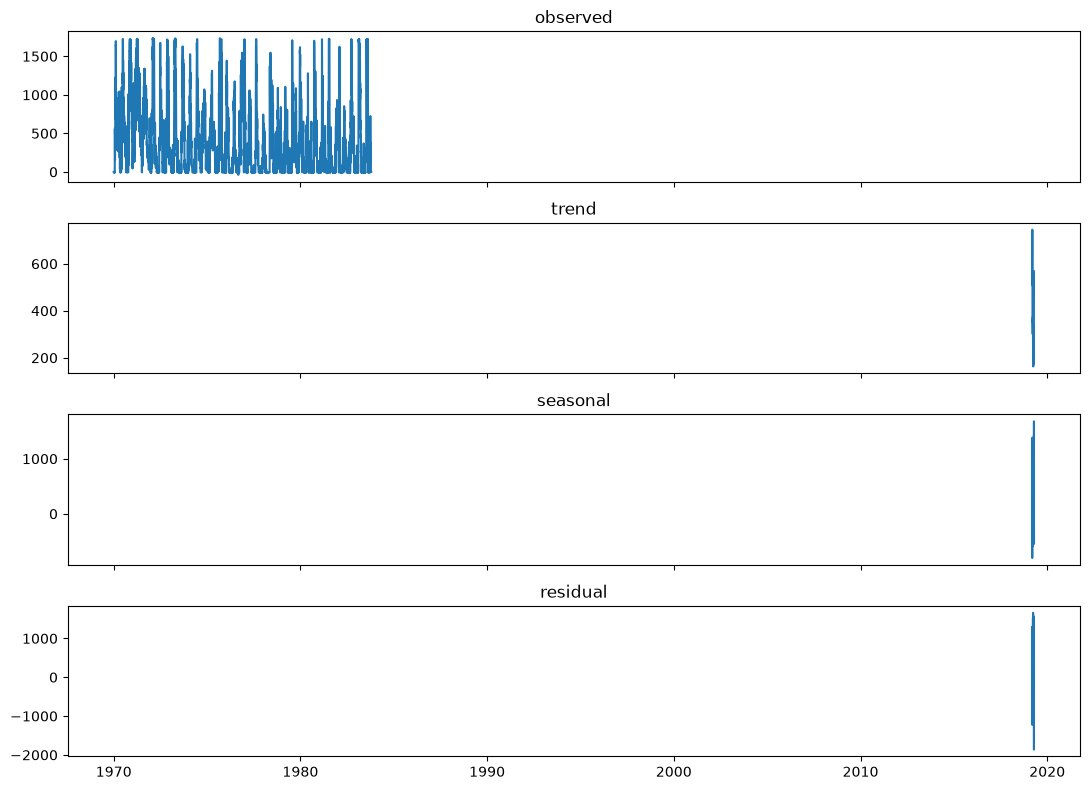

trend strength: 0.196, seasonal strength: 0.573

store-sales
count     1458.000000
mean      1551.122622
std       2211.497717
min          0.000000
25%        119.627000
50%        797.929000
75%       2043.331500
max      28106.716000
Name: Sales, dtype: float64
skew: 3.401, kurtosis: 21.587
extreme outliers (3x IQR): 32 (2.19%)


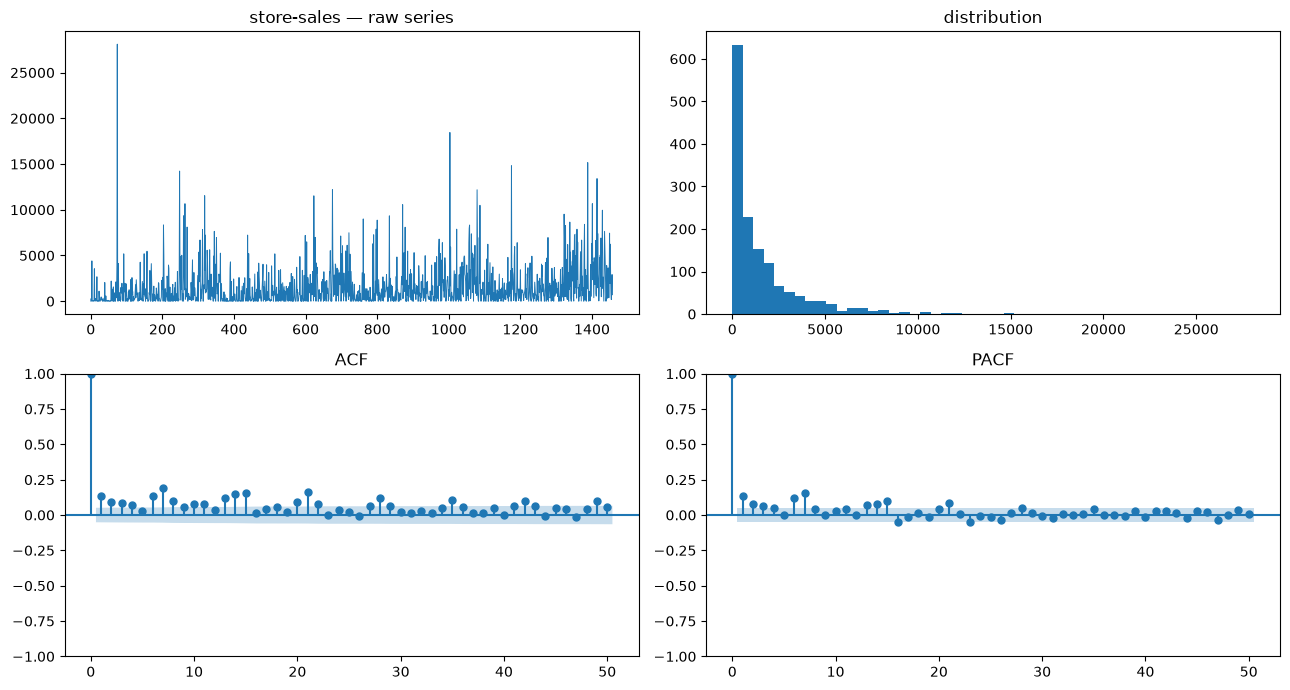

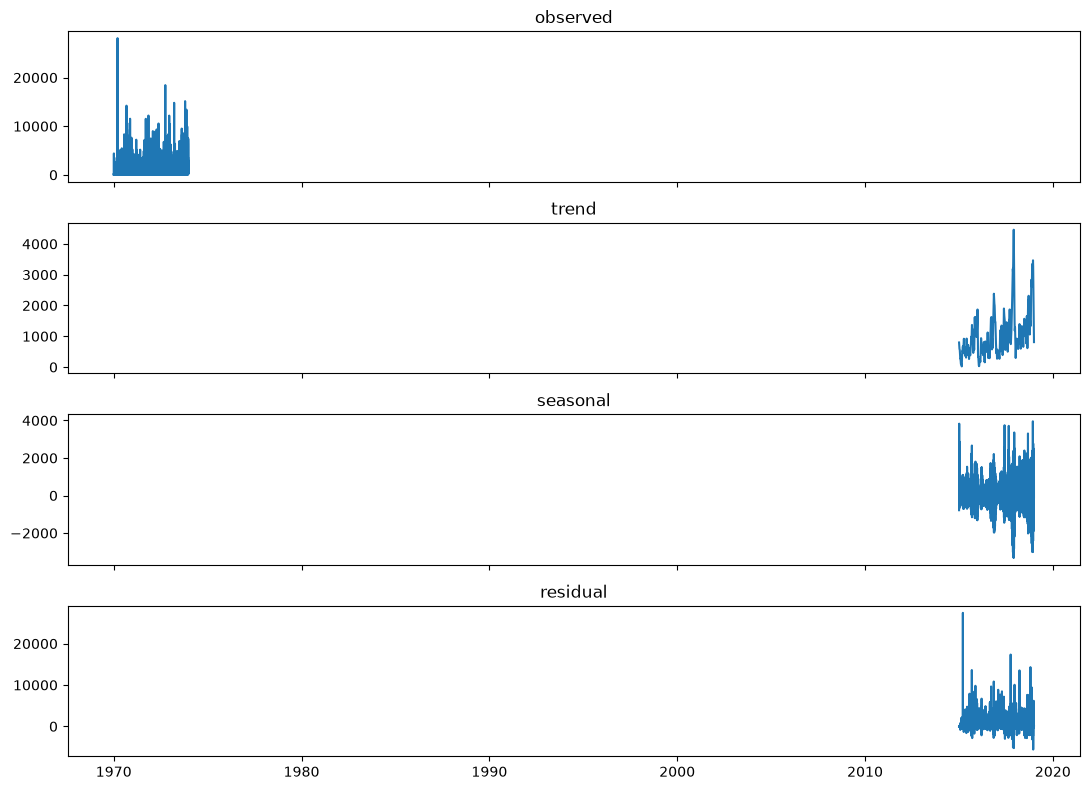

trend strength: 0.125, seasonal strength: 0.143

antarctica-climate
count    7305.000000
mean       -4.973717
std         5.178413
min       -26.200000
25%        -8.100000
50%        -3.600000
75%        -1.000000
max         6.100000
Name: temperature_2m_mean, dtype: float64
skew: -0.924, kurtosis: 0.404
extreme outliers (3x IQR): 0 (0.00%)


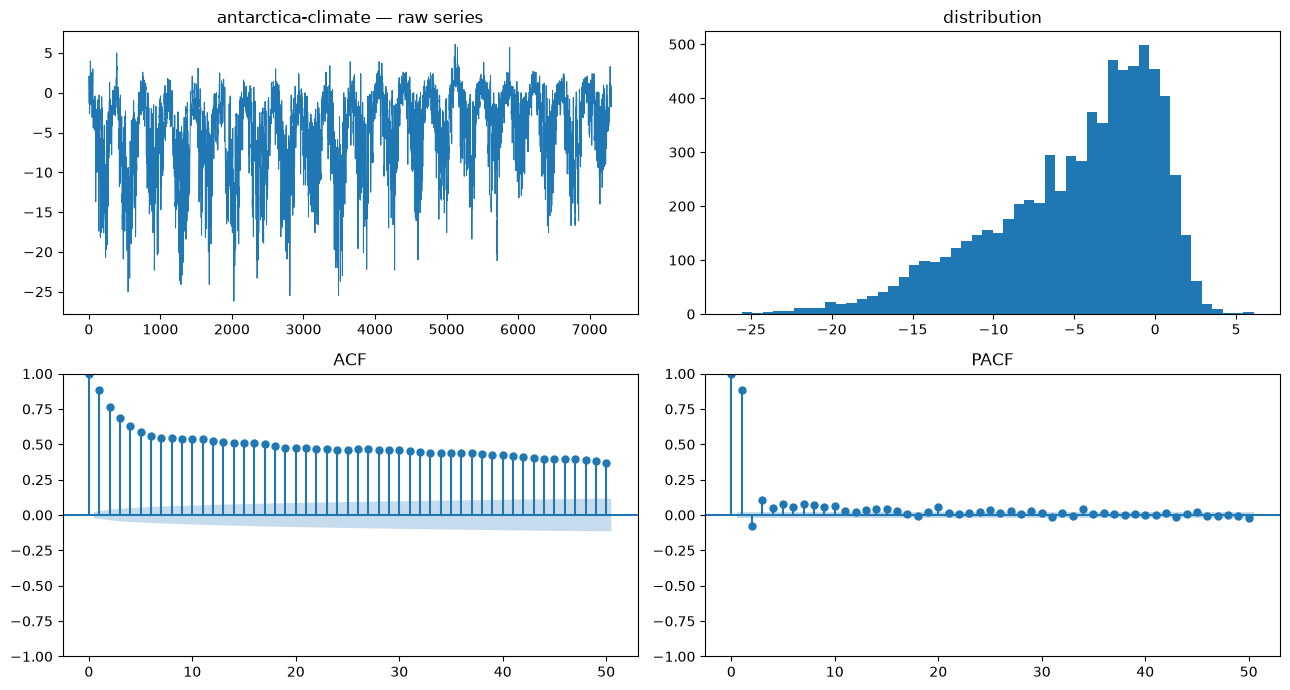

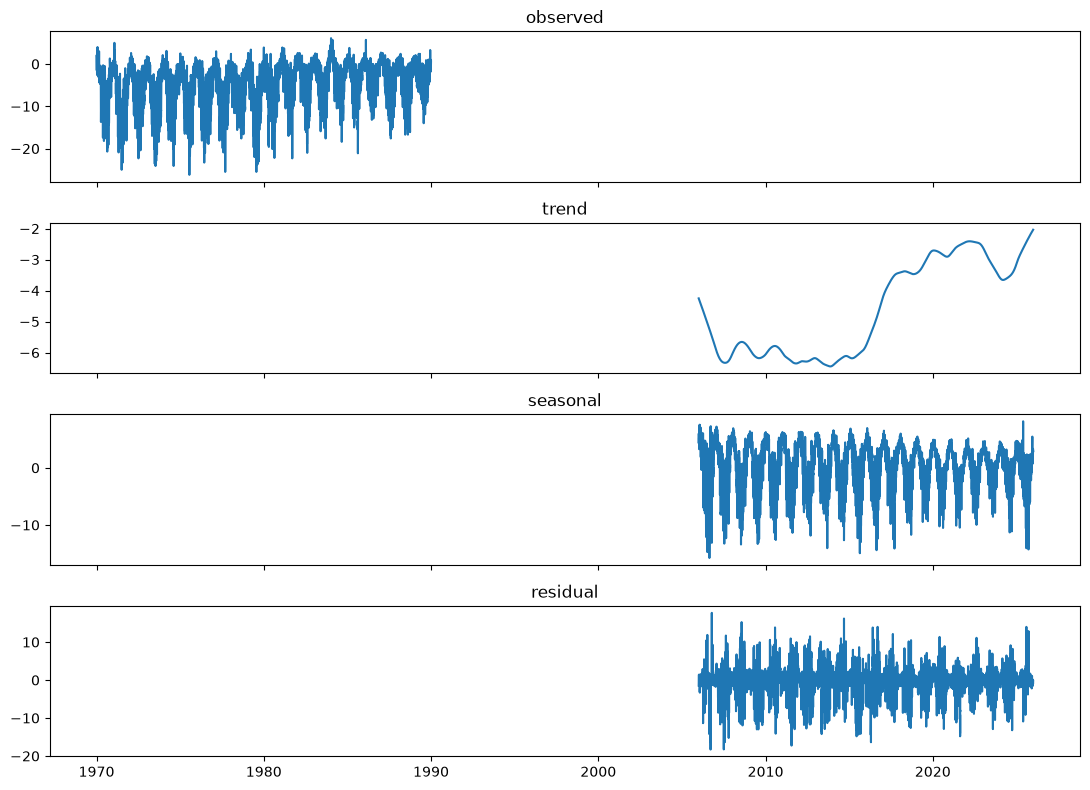

trend strength: 0.204, seasonal strength: 0.554

traffic
count    17544.000000
mean         0.031537
std          0.019453
min          0.000000
25%          0.012500
50%          0.034100
75%          0.046700
max          0.217400
Name: OT, dtype: float64
skew: 0.192, kurtosis: -0.237
extreme outliers (3x IQR): 2 (0.01%)


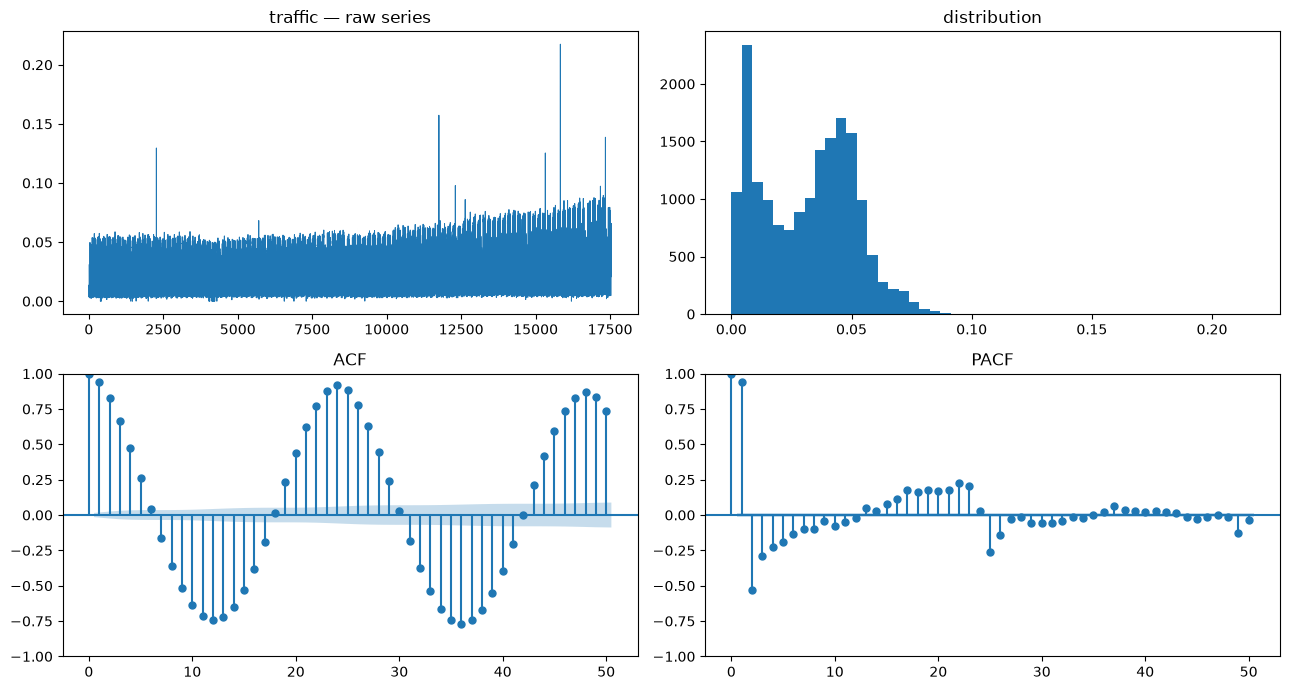

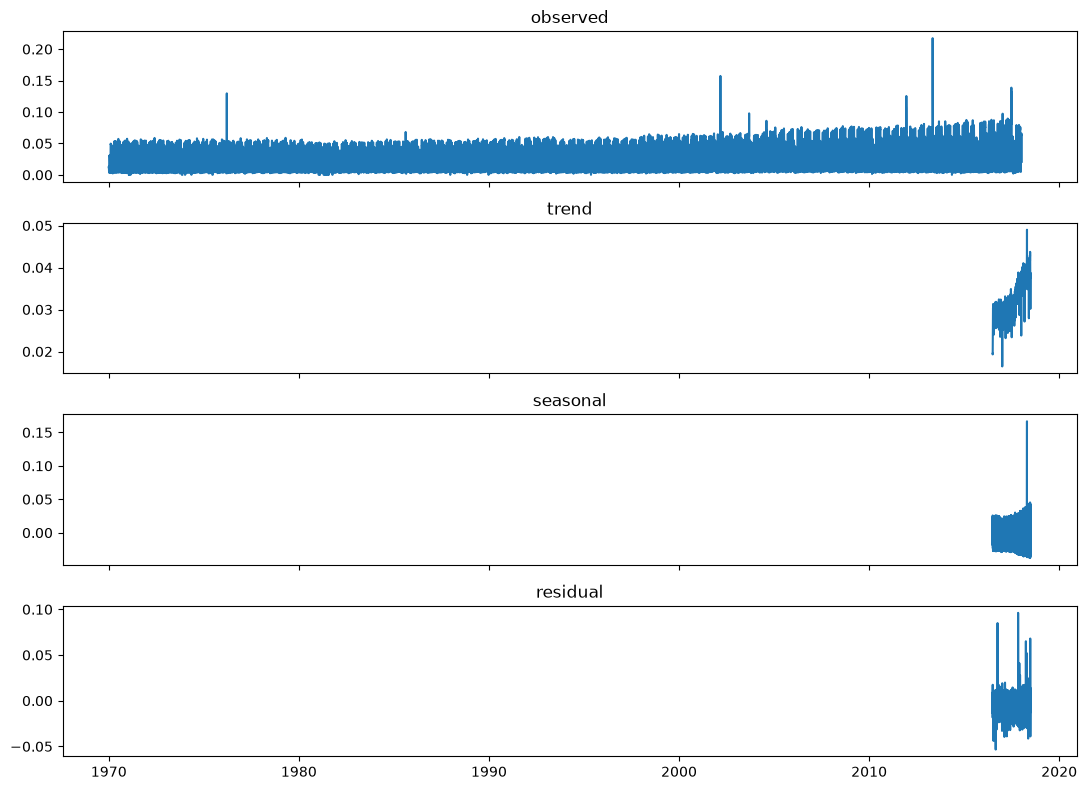

trend strength: 0.425, seasonal strength: 0.916


In [ ]:
SEASONAL_PERIODS = {
    "motor-temp": None,             # no obvious cyclical seasonality expected
    "wind-power": 144,              # 144 * 10min = daily cycle
    "store-sales": 7,               # weekly cycle
    "antarctica-climate": 365,      # annual cycle
    "traffic": 24,                  # hourly data, daily cycle
}

EDA_RESULTS = {}
for name, s in SERIES.items():
    EDA_RESULTS[name] = run_eda(name, s, seasonal_period=SEASONAL_PERIODS[name])

### Check the log of store-sales


store-sales (log1p)
count    1458.000000
mean        5.672878
std         2.809784
min         0.000000
25%         4.792702
50%         6.683272
75%         7.622826
max        10.243799
Name: Sales, dtype: float64
skew: -1.084, kurtosis: -0.086
extreme outliers (3x IQR): 0 (0.00%)


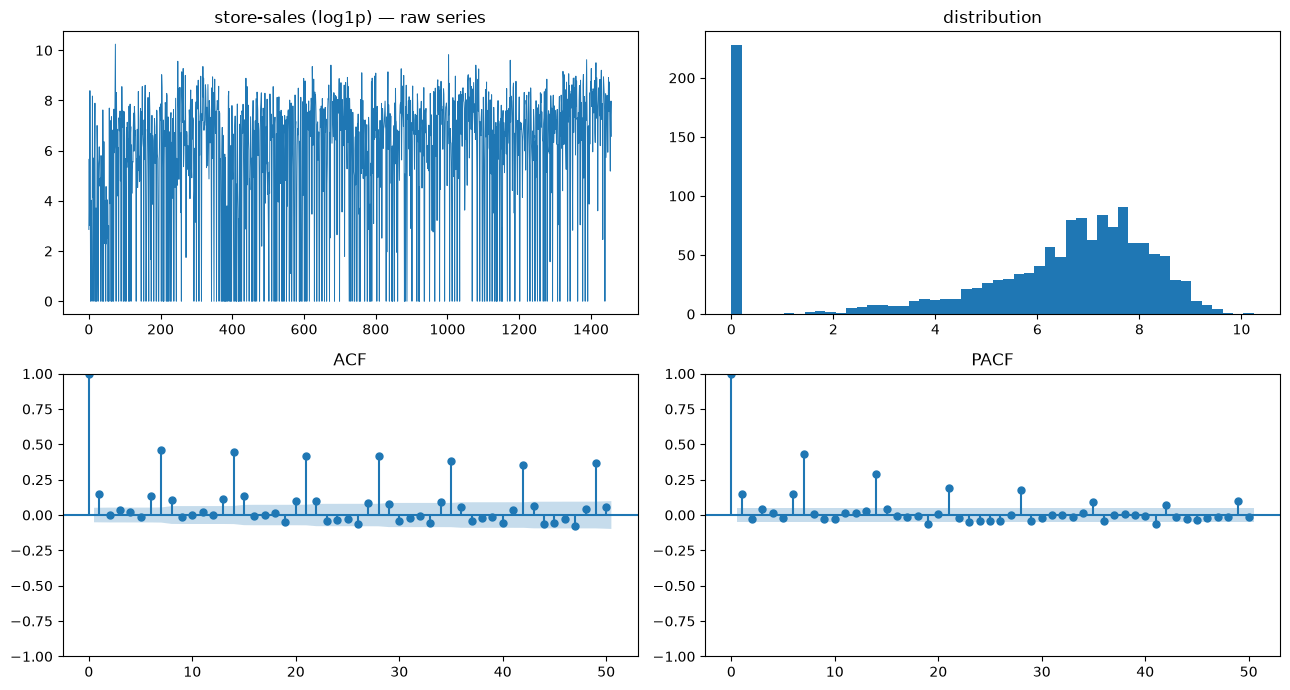

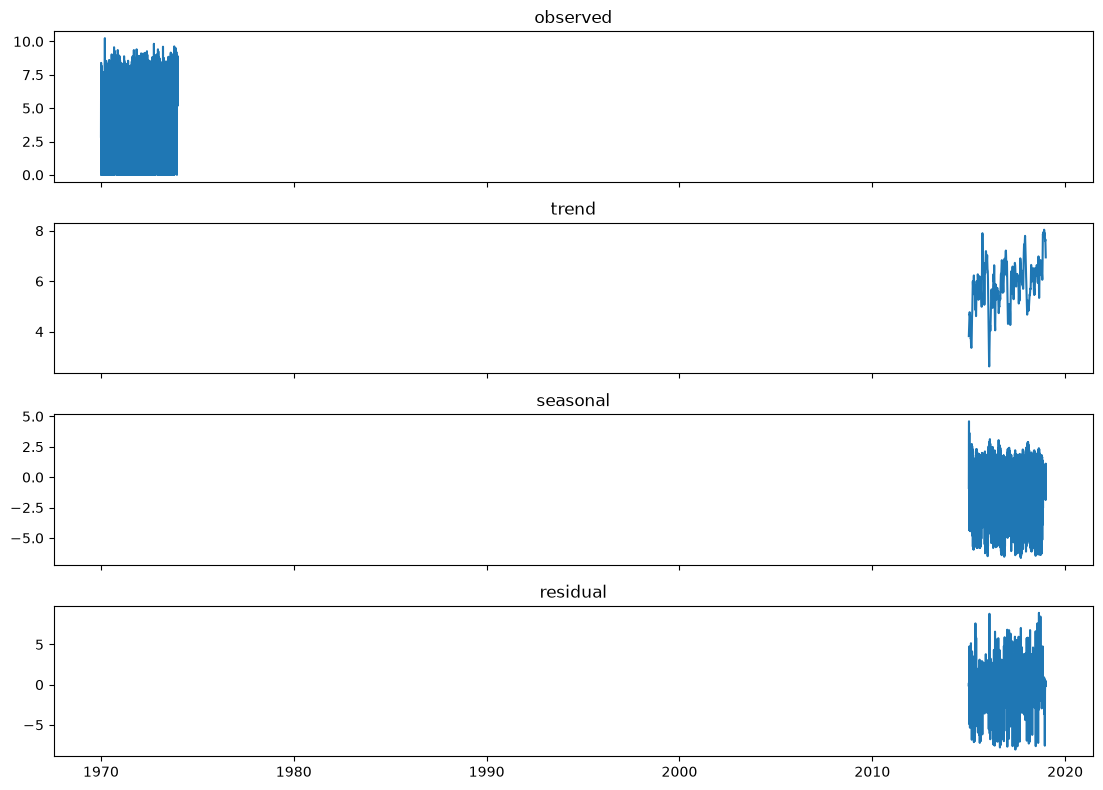

trend strength: 0.207, seasonal strength: 0.421


{'n': 1458,
 'mean': np.float64(5.672877764041947),
 'std': np.float64(2.8097843265224496),
 'skew': np.float64(-1.084226252419399),
 'kurtosis': np.float64(-0.08614601207114658),
 'n_outliers': 0}

In [28]:
log_sales = np.log1p(SERIES["store-sales"])
run_eda("store-sales (log1p)", log_sales, seasonal_period=7)

## EDA - Features

In [31]:
def lagged_correlation(target, feature, max_lag=20):
    """
    Returns a dict {lag: correlation} for lag in [-max_lag, max_lag].
    Positive lag: feature[t - lag] vs target[t]  (feature LEADS target — useful for forecasting)
    Negative lag: feature[t - lag] vs target[t]  (feature LAGS target — feature moves after target)
    """
    results = {}
    for lag in range(-max_lag, max_lag + 1):
        shifted_feature = feature.shift(lag)
        valid = shifted_feature.notna() & target.notna()
        if valid.sum() < 2:
            results[lag] = np.nan
            continue
        results[lag] = np.corrcoef(target[valid], shifted_feature[valid])[0, 1]
    return results

In [64]:
def feature_eda(df, target_col, feature_cols, name, max_lag=20):
    print(f"\n{'='*60}\n{name} — feature relationships to '{target_col}'\n{'='*60}")

    # Correlation table
    corr = df[[target_col] + feature_cols].corr()[target_col].drop(target_col)
    print("\nCorrelation with target at same time:")
    print(corr.sort_values(key=abs, ascending=False))

    # Scatter plots: feature vs target
    n = len(feature_cols)
    fig, axes = plt.subplots(1, n, figsize=(5 * n, 4))
    if n == 1:
        axes = [axes]
    for ax, col in zip(axes, feature_cols):
        ax.scatter(df[col], df[target_col], s=2, alpha=0.3)
        ax.set_xlabel(col)
        ax.set_ylabel(target_col)
        ax.set_title(f"{col} vs {target_col}\ncorr={corr[col]:.3f}")
    plt.tight_layout()
    plt.show()

    # Lagged correlation tables
    fig, axes = plt.subplots(1, n, figsize=(5 * n, 4))
    if n == 1:
        axes = [axes]
    for ax, col in zip(axes, feature_cols):
        lag_corrs = lagged_correlation(df[target_col], df[col], max_lag=max_lag)
        lags = list(lag_corrs.keys())
        vals = list(lag_corrs.values())
        ax.stem(lags, vals)
        ax.axvline(0, color="grey", linestyle="--", linewidth=0.8)
        ax.set_title(f"lagged corr: {col} vs {target_col}")
        ax.set_xlabel("lag (positive = feature leads target)")
        ax.set_ylabel("correlation")
    plt.tight_layout()
    plt.show()

    # Distribution of each feature
    fig, axes = plt.subplots(1, n, figsize=(5 * n, 3))
    if n == 1:
        axes = [axes]
    for ax, col in zip(axes, feature_cols):
        ax.hist(df[col].dropna(), bins=50)
        skew = df[col].skew()
        ax.set_title(f"{col} (skew={skew:.2f})")
    plt.tight_layout()
    plt.show()

    return corr

### Undifferenced Test


motor-temp — feature relationships to 'pm'

Correlation with target at same time:
stator_winding    0.855446
stator_tooth      0.840940
stator_yoke       0.692662
ambient           0.574102
motor_speed       0.444887
torque            0.265585
coolant           0.237348
Name: pm, dtype: float64


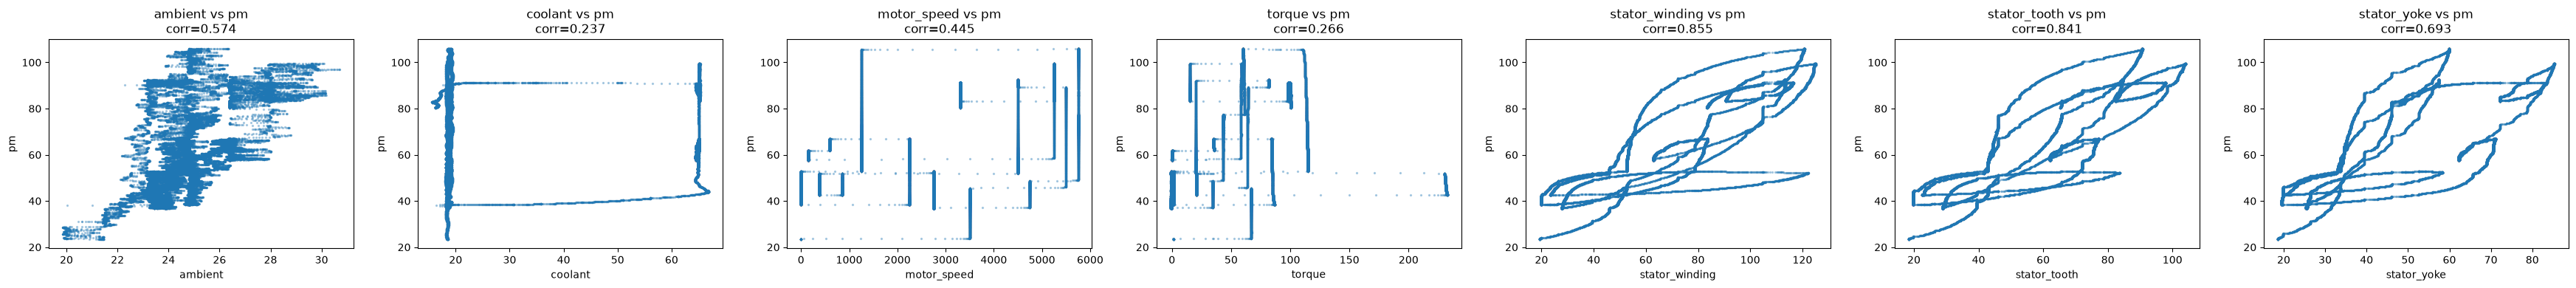

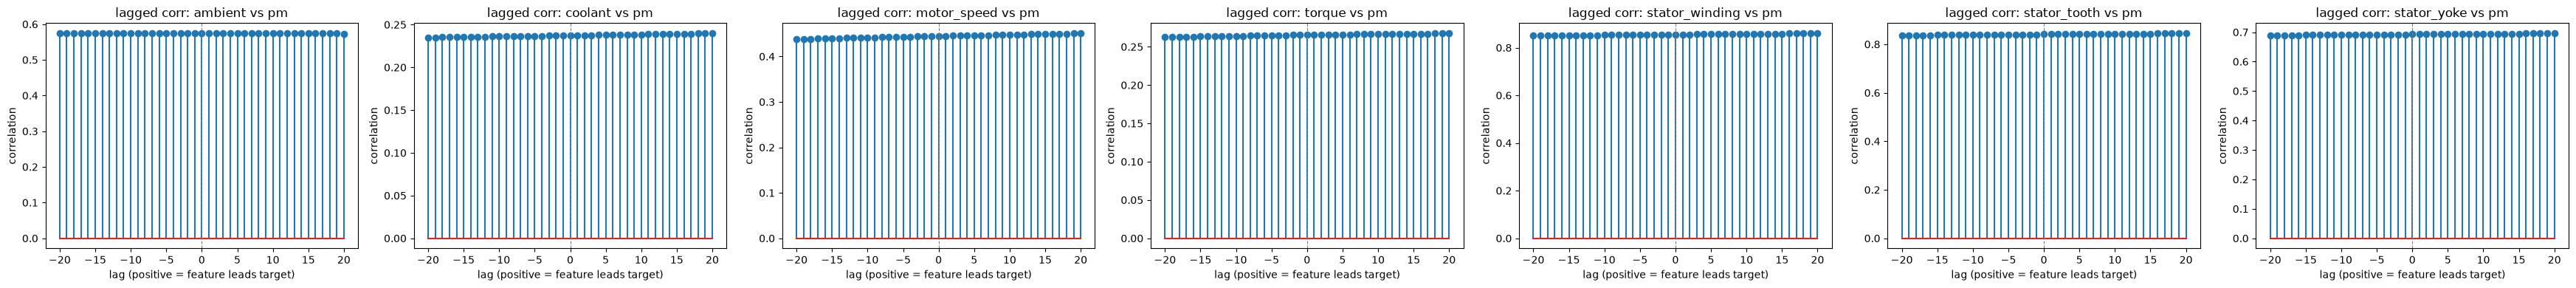

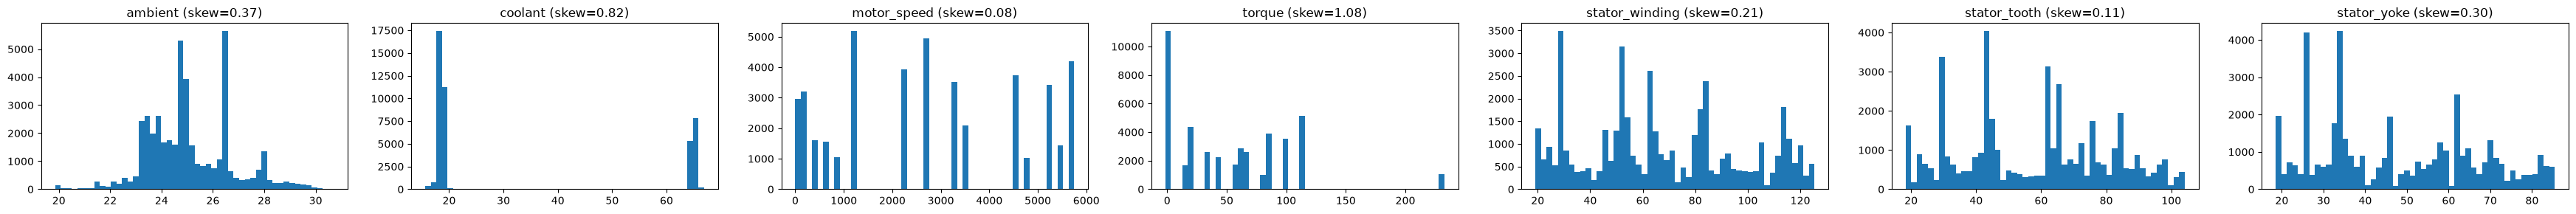

In [ ]:
# motor-temp: pm target
considered_target_and_features = ["pm", "ambient", "coolant", "motor_speed", "torque", "stator_winding", "stator_tooth", "stator_yoke"]
motor_df = RAW["motor-temp"][RAW["motor-temp"]["profile_id"] == chosen_profile].reset_index(drop=True)
motor_corr = feature_eda(
    motor_df, target_col=considered_target_and_features[0],
    feature_cols=considered_target_and_features[1:],
    name="motor-temp",
)

In [66]:
motor_df

,u_q,coolant,stator_winding,u_d,stator_tooth,motor_speed,i_d,i_q,pm,stator_yoke,ambient,torque,profile_id
0,-0.744542,18.425650,19.178789,0.889181,18.359369,-0.002219,-1.967667,1.078725,23.549839,18.586605,21.449112,1.036889,20
1,-0.694687,18.428200,19.200027,0.582004,18.353622,-0.003303,-1.972967,1.082107,23.563290,18.587828,21.378757,1.230241,20
2,-0.854873,18.435112,19.231150,0.632166,18.347399,-0.001806,-1.977448,1.084059,23.558455,18.595362,21.377003,1.286205,20
3,-0.784175,18.468853,19.237148,0.753127,18.346460,-0.001795,-1.717716,0.942433,23.548714,18.590996,21.375832,1.399333,20
4,-0.894451,18.510260,19.252317,0.760415,18.329735,-0.001788,-1.797068,0.987981,23.538948,18.598888,21.365734,1.433973,20
...,...,...,...,...,...,...,...,...,...,...,...,...,...
43966,52.157505,16.302113,83.513901,-120.541763,65.286514,3299.958984,-153.348175,109.035484,80.373520,45.986176,26.384508,100.277405,20
43967,52.159737,16.276432,83.488213,-120.575165,65.311539,3299.958984,-153.369965,109.048035,80.374466,45.986176,26.384508,100.265114,20
43968,52.183811,16.245003,83.512695,-120.567604,65.298050,3299.962646,-153.358322,109.043701,80.377335,45.986176,26.384508,100.241371,20
43969,52.201317,16.242159,83.561462,-120.561684,65.310745,3299.962402,-153.343796,109.055847,80.379944,45.986176,26.384508,100.264709,20



wind-power — feature relationships to 'ActivePower'

Correlation with target at same time:
WindSpeed            0.940719
RotorRPM             0.808360
NacellePosition     -0.192099
WindDirection       -0.192099
AmbientTemperatue   -0.156255
Name: ActivePower, dtype: float64


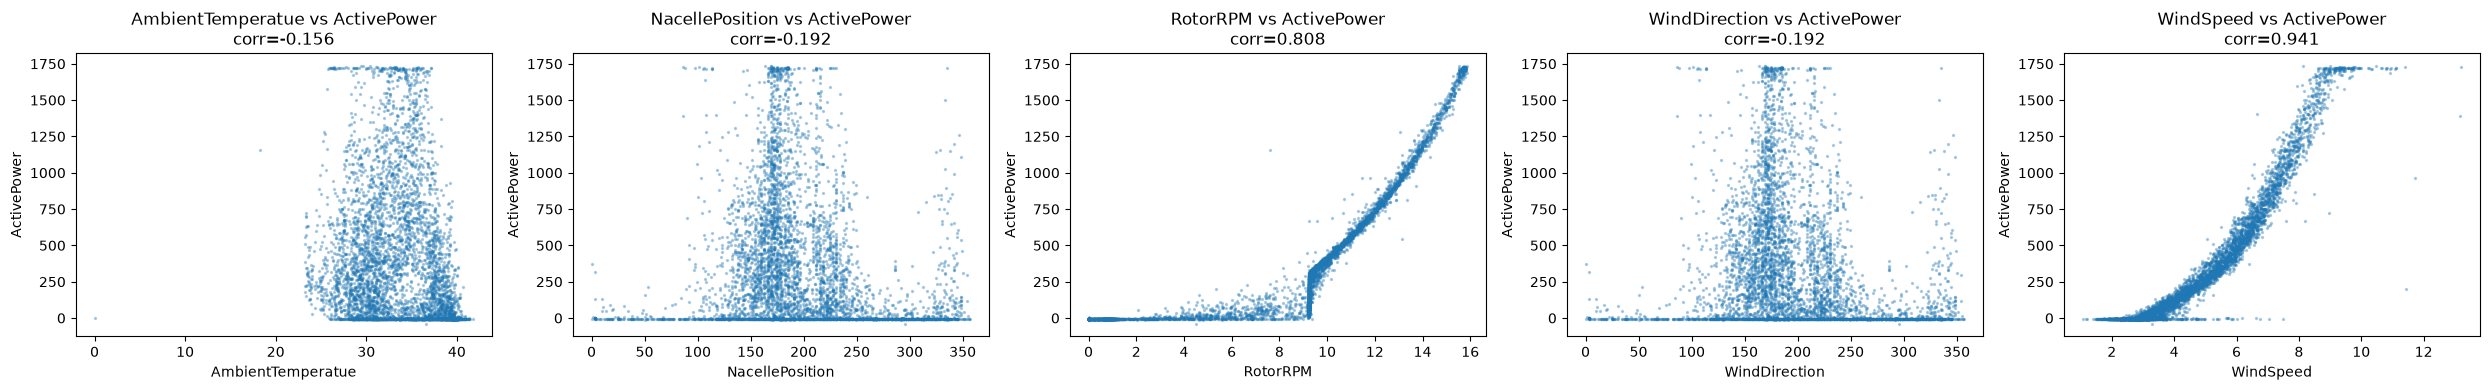

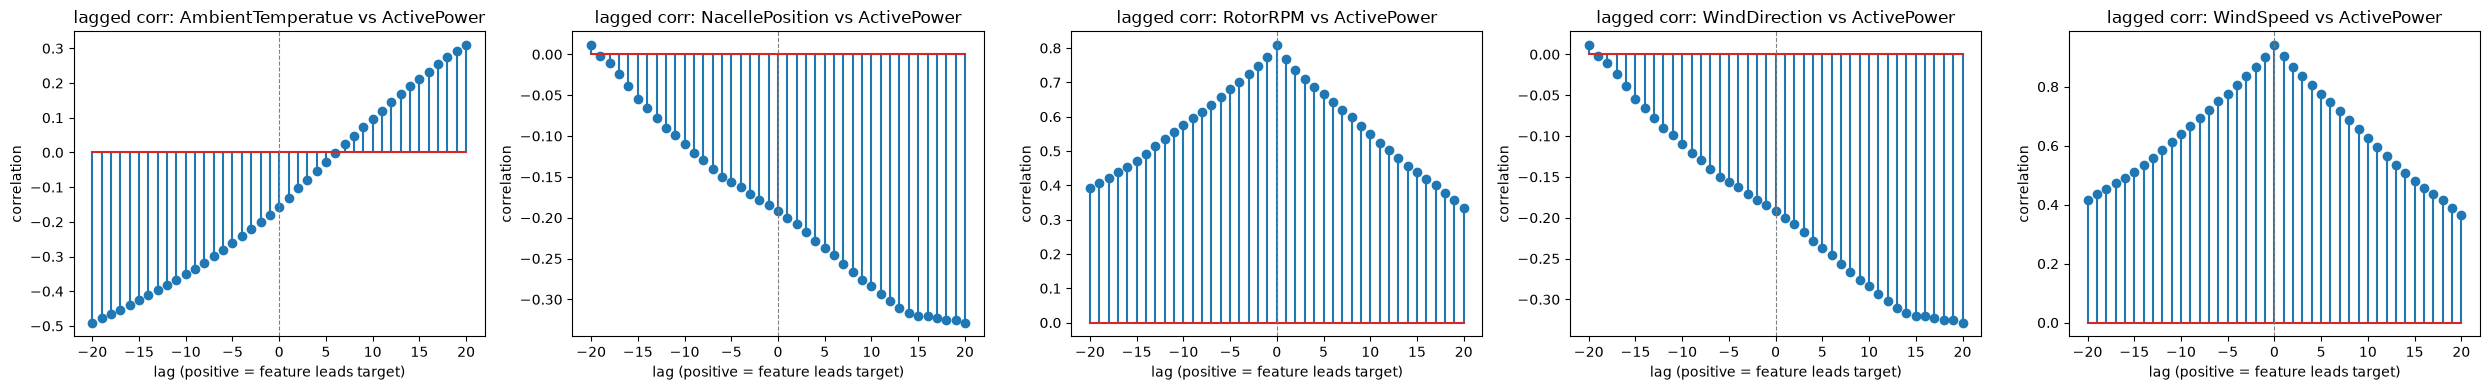

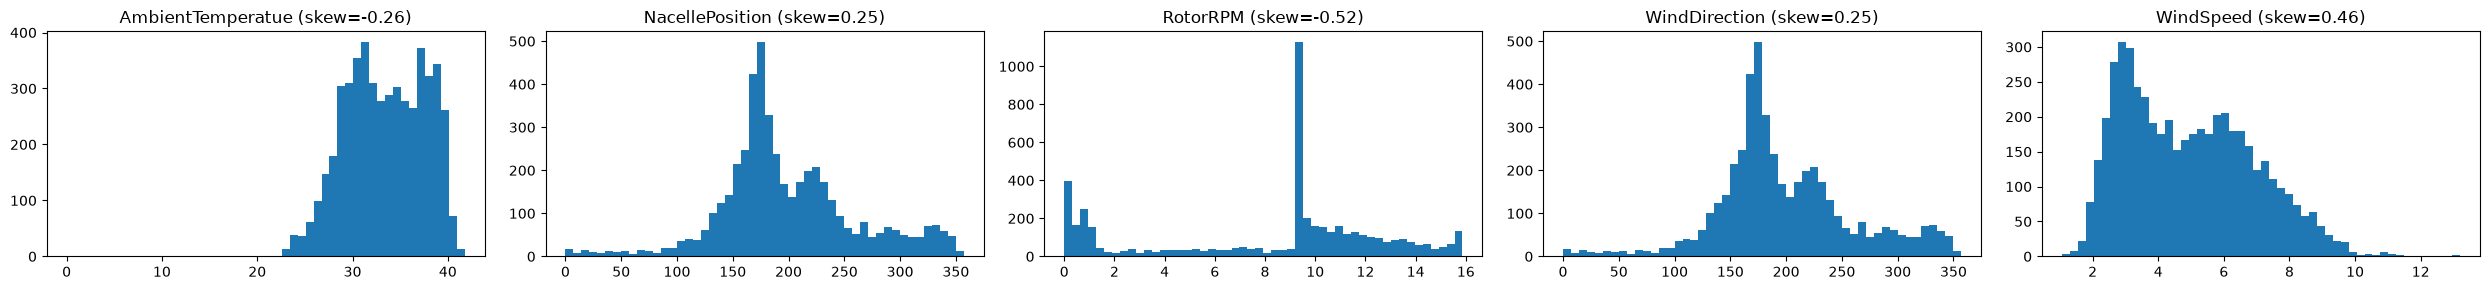

In [ ]:
# wind-power: ActivePower target
considered_target_and_features = ["ActivePower", "AmbientTemperatue", "NacellePosition", "RotorRPM", "WindDirection", "WindSpeed"]
wind_df = RAW["wind-power"].rename(columns={"Unnamed: 0": "timestamp"})
wind_df["timestamp"] = pd.to_datetime(wind_df["timestamp"])
wind_df = wind_df.set_index("timestamp").sort_index()
wind_df = wind_df[considered_target_and_features]
first_valid = wind_df["ActivePower"].first_valid_index()
wind_df = wind_df.loc[first_valid:].interpolate(method="linear", limit=3)
# align to the same clean run you isolated earlier
wind_df = wind_df.loc[SERIES["wind-power"].index]

wind_corr = feature_eda(
    wind_df, target_col=considered_target_and_features[0],
    feature_cols=considered_target_and_features[1:],
    name="wind-power",
)

In [68]:
print(wind_df[["WindSpeed", "RotorRPM"]].corr())

           WindSpeed  RotorRPM
WindSpeed   1.000000  0.871886
RotorRPM    0.871886  1.000000


In [69]:
wind_df

,ActivePower,AmbientTemperatue,NacellePosition,RotorRPM,WindDirection,WindSpeed
timestamp,,,,,,
2019-03-13 07:20:00+00:00,0.000000,35.003857,295.000000,0.0,295.000000,1.743200
2019-03-13 07:30:00+00:00,-1.781925,35.552129,280.555556,0.0,280.555556,2.126894
2019-03-13 07:40:00+00:00,-3.563849,36.100402,266.111111,0.0,266.111111,2.510587
2019-03-13 07:50:00+00:00,-5.345774,36.648674,251.666667,0.0,251.666667,2.894281
2019-03-13 08:00:00+00:00,-7.127699,37.196947,237.222222,0.0,237.222222,3.277975
...,...,...,...,...,...,...
2019-04-17 06:20:00+00:00,0.000000,36.938801,3.000000,0.0,3.000000,3.008008
2019-04-17 06:30:00+00:00,0.000000,37.102978,3.000000,0.0,3.000000,2.751300
2019-04-17 06:40:00+00:00,0.000000,37.102978,3.000000,0.0,3.000000,2.751300


### With Differenced Data


motor-temp (differenced) — feature relationships to 'pm'

Correlation with target at same time:
stator_tooth      0.401317
stator_winding    0.329918
stator_yoke       0.306779
motor_speed       0.029948
coolant           0.007370
torque            0.003960
ambient           0.000439
Name: pm, dtype: float64


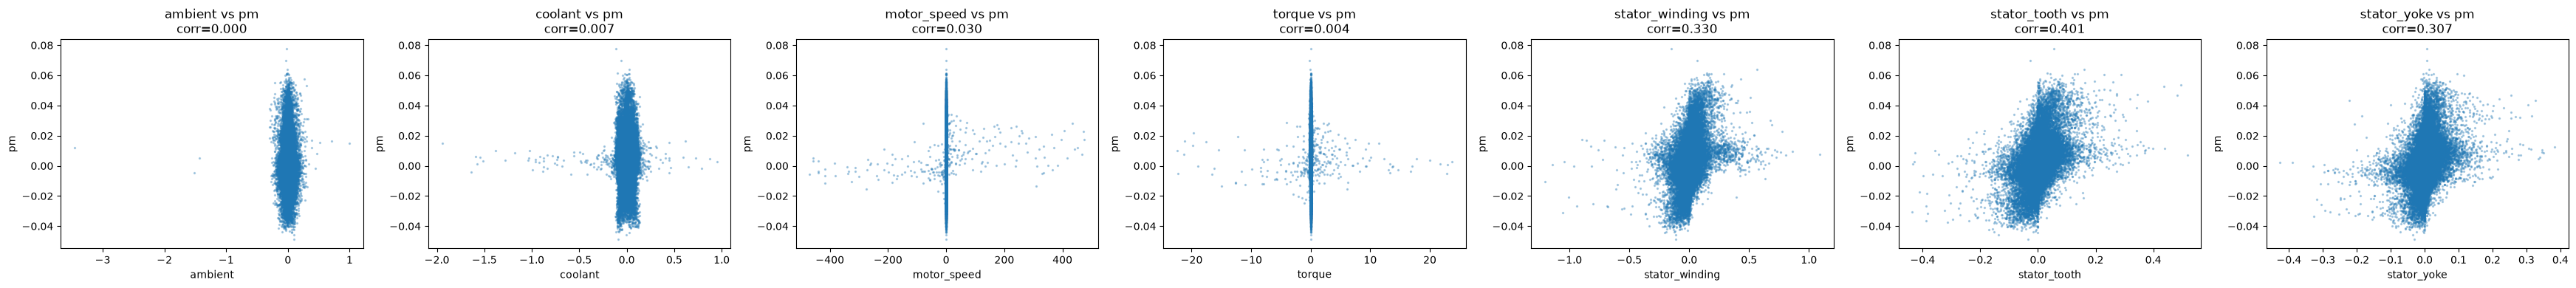

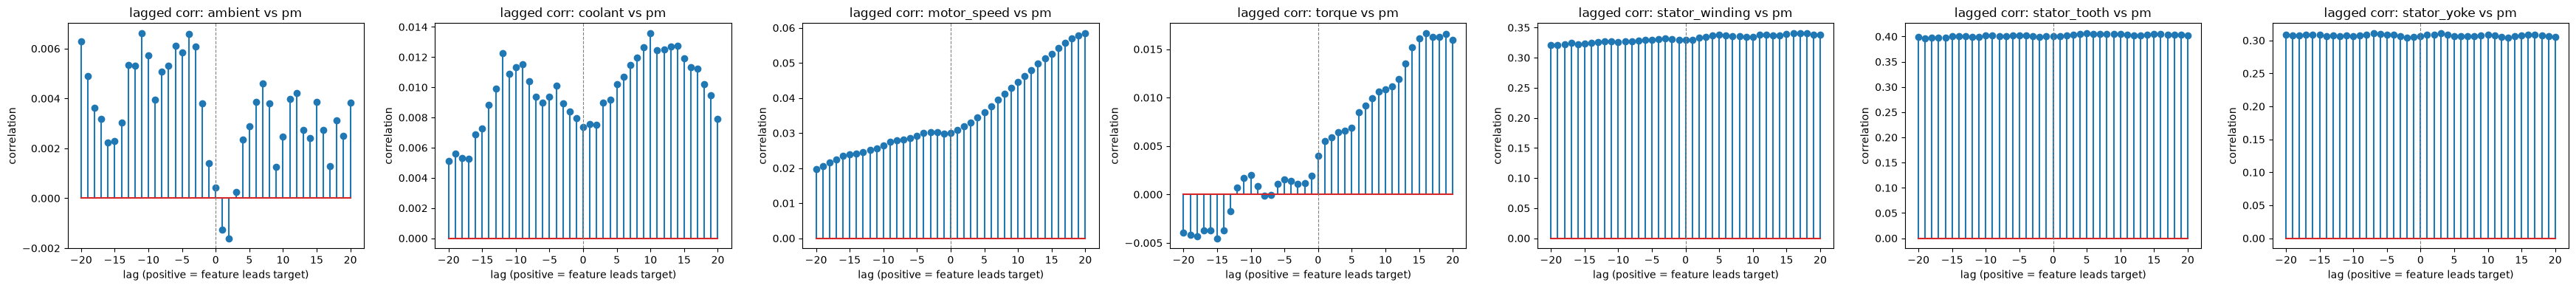

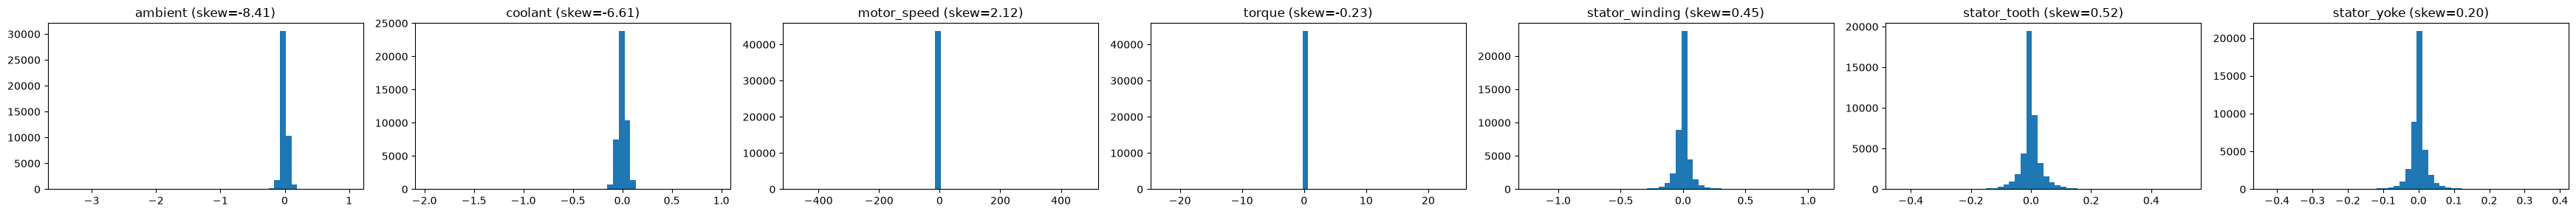

In [ ]:
# motor-temp: pm target
considered_target_and_features = ["pm", "ambient", "coolant", "motor_speed", "torque", "stator_winding", "stator_tooth", "stator_yoke"]
motor_df = RAW["motor-temp"][RAW["motor-temp"]["profile_id"] == chosen_profile].reset_index(drop=True)
motor_df_diff = motor_df[considered_target_and_features].diff().dropna()
motor_corr = feature_eda(
    motor_df_diff, target_col=considered_target_and_features[0],
    feature_cols=considered_target_and_features[1:],
    name="motor-temp (differenced)",
)

### Wind


wind-power (differenced) — feature relationships to 'ActivePower'

Correlation with target at same time:
WindSpeed            0.729626
RotorRPM             0.489401
AmbientTemperatue   -0.037203
NacellePosition      0.005619
WindDirection        0.005619
Name: ActivePower, dtype: float64


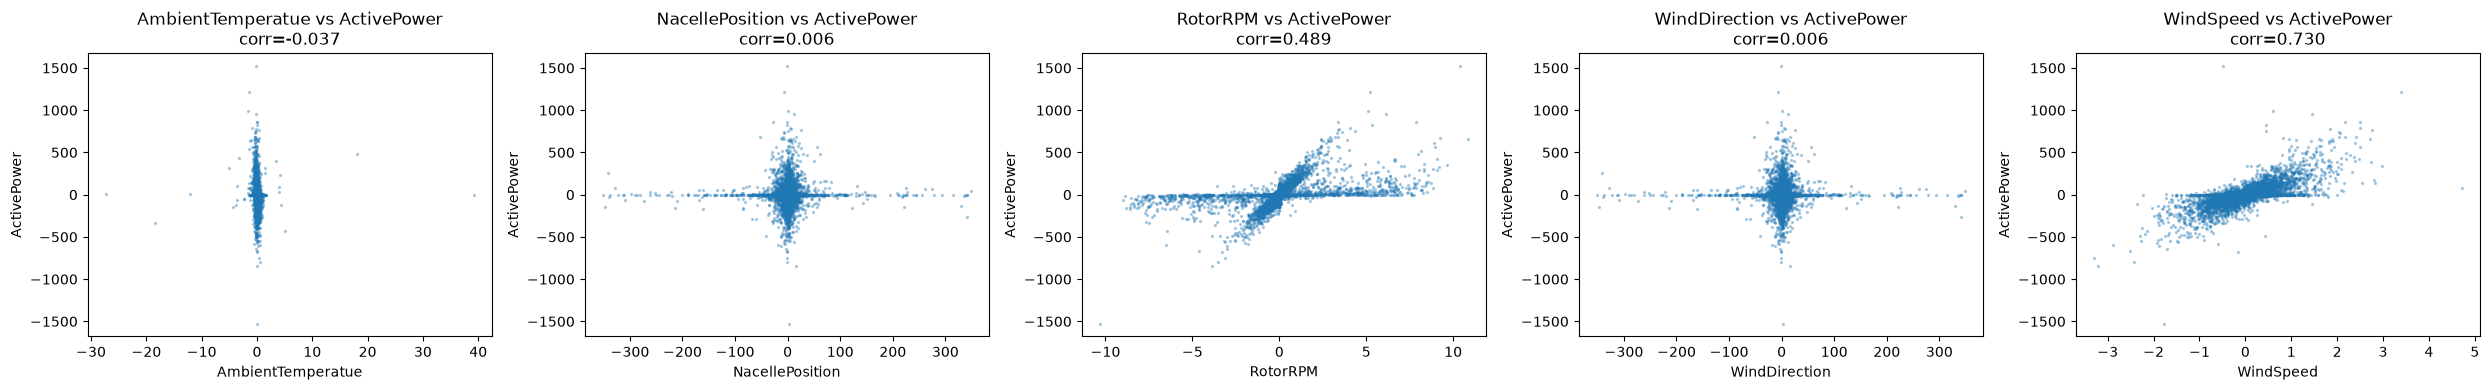

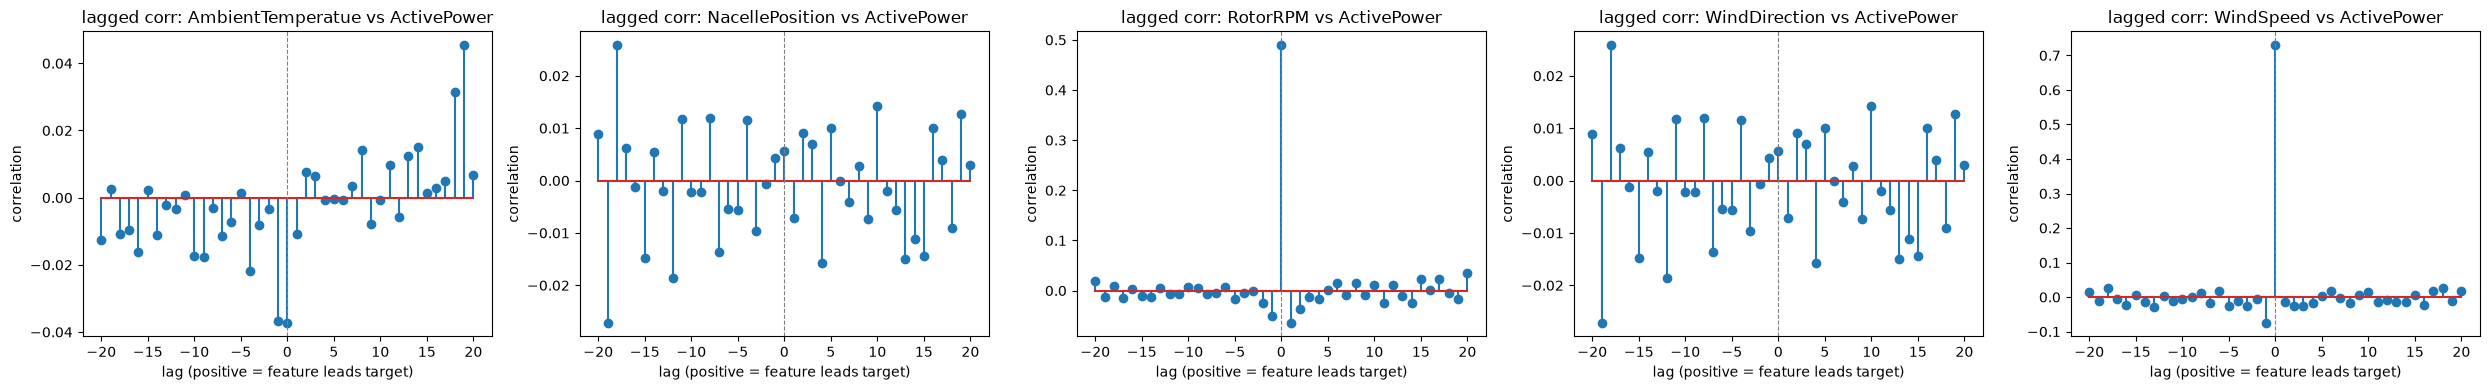

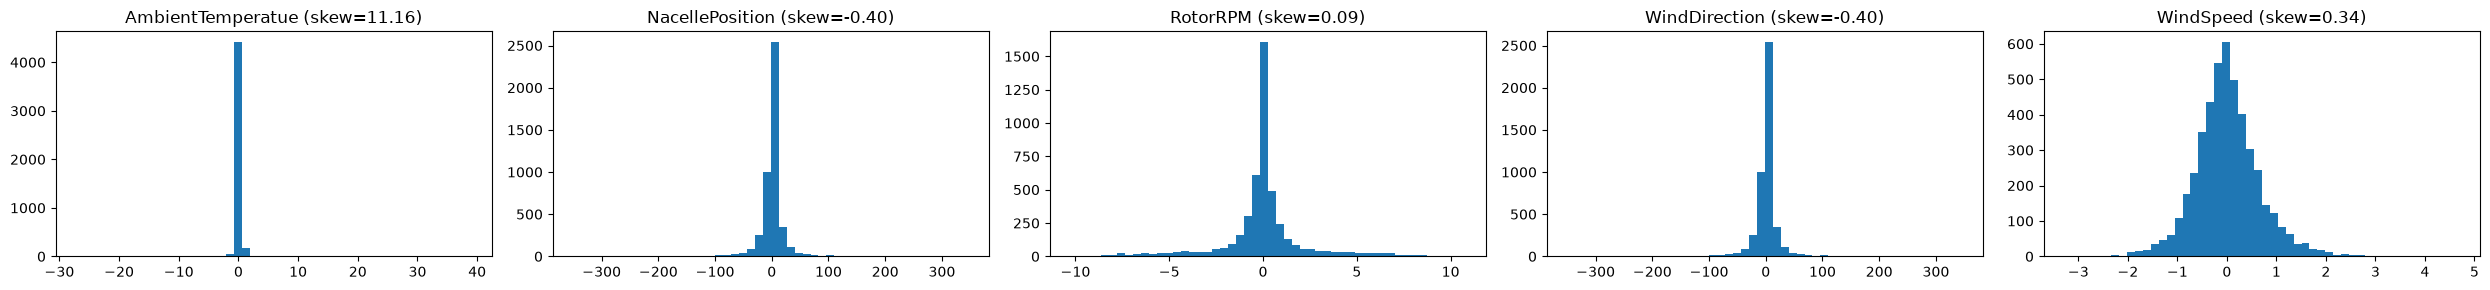

In [ ]:
considered_target_and_features = ["ActivePower", "AmbientTemperatue", "NacellePosition", "RotorRPM", "WindDirection", "WindSpeed"]
wind_df_diff = wind_df[considered_target_and_features].diff().dropna()

wind_corr_diff = feature_eda(
    wind_df_diff, target_col=considered_target_and_features[0],
    feature_cols=considered_target_and_features[1:],
    name="wind-power (differenced)",
)

In [83]:
print(wind_df_diff[["WindSpeed", "RotorRPM"]].corr())

           WindSpeed  RotorRPM
WindSpeed   1.000000  0.473463
RotorRPM    0.473463  1.000000


#### Antarctica


antarctica-climate (differenced) — feature relationships to 'temperature_2m_mean'

Correlation with target at same time:
precipitation_hours            0.436527
precipitation_sum              0.388238
sunshine_duration             -0.284731
wind_direction_10m_dominant   -0.185939
rain_sum                       0.108332
wind_speed_10m_max            -0.022663
wind_gusts_10m_max             0.019516
Name: temperature_2m_mean, dtype: float64


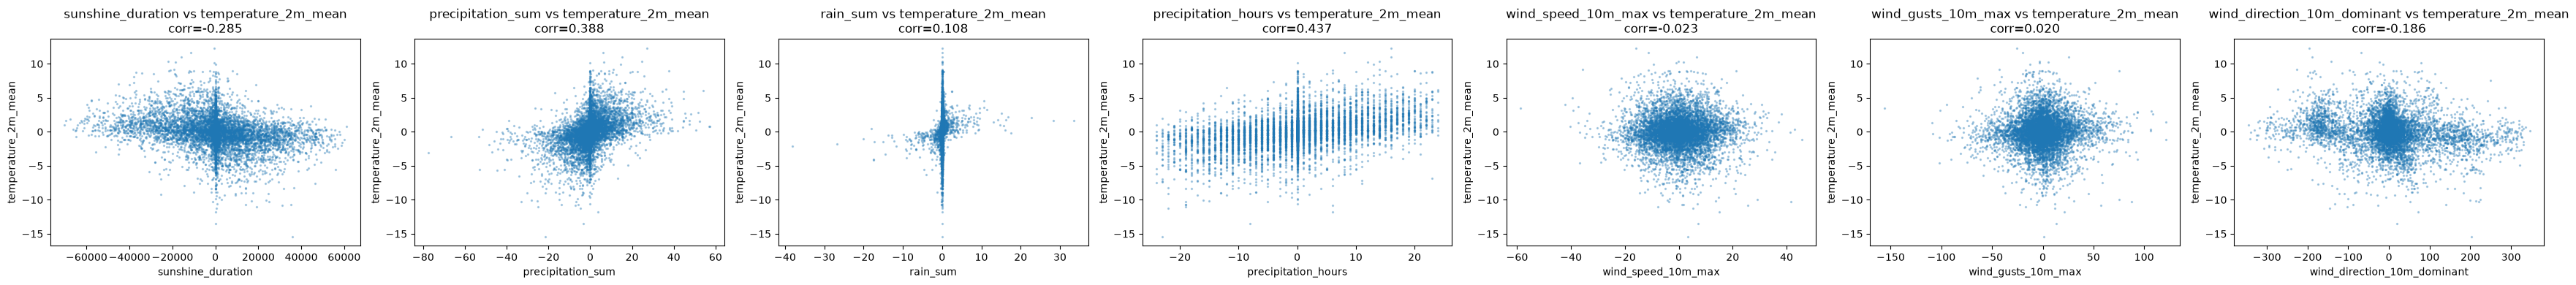

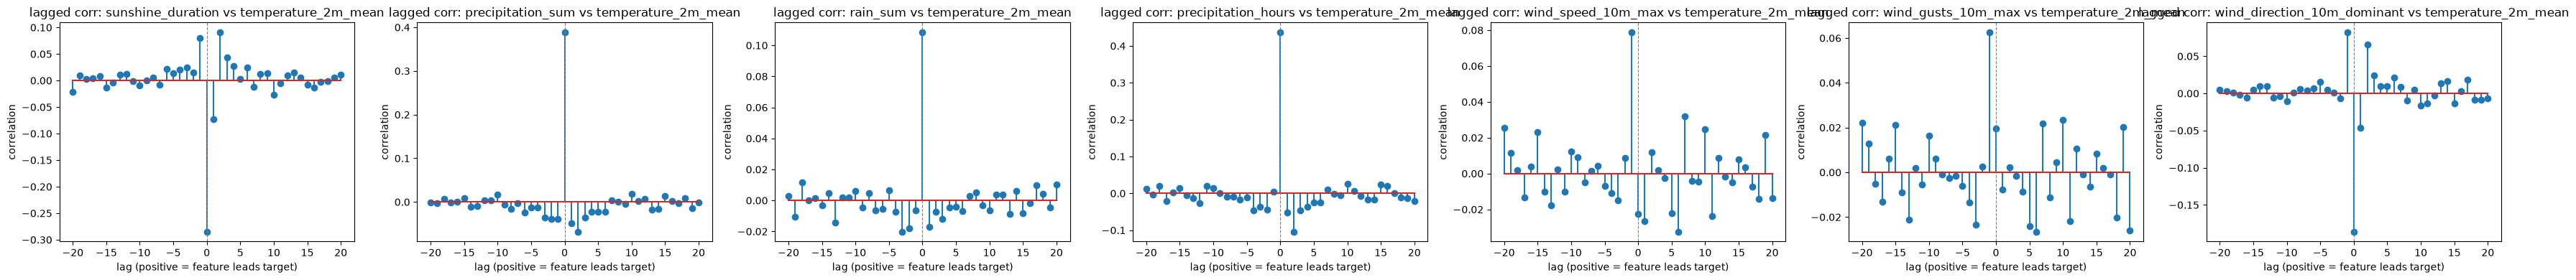

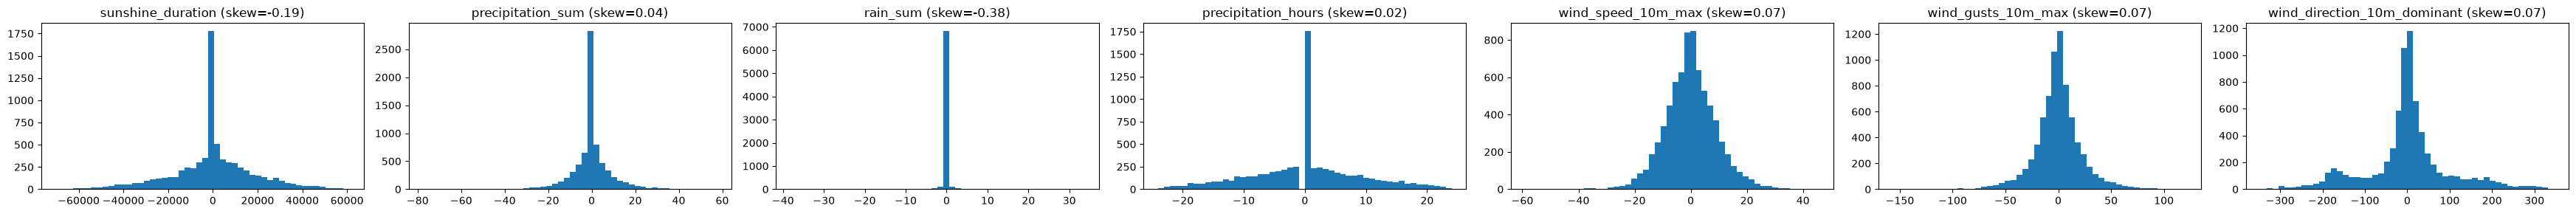

In [80]:
considered_target_and_features = ["temperature_2m_mean", "sunshine_duration", "precipitation_sum", "rain_sum", "precipitation_hours",	"wind_speed_10m_max",	"wind_gusts_10m_max",	"wind_direction_10m_dominant"]
antarctica_df = RAW["antarctica-climate"][RAW["antarctica-climate"]["location"] == chosen_location].copy()
antarctica_df["date"] = pd.to_datetime(antarctica_df["date"])
antarctica_df = antarctica_df.set_index("date").sort_index()

antarctica_df_diff = antarctica_df[considered_target_and_features].diff().dropna()

antarctica_corr_diff = feature_eda(
    antarctica_df_diff, target_col=considered_target_and_features[0],
    feature_cols=considered_target_and_features[1:],
    name="antarctica-climate (differenced)",
)

In [78]:
antarctica_df

,location,latitude,longitude,weather_code,temperature_2m_mean,temperature_2m_max,temperature_2m_min,precipitation_sum,rain_sum,precipitation_hours,wind_speed_10m_max,wind_gusts_10m_max,wind_direction_10m_dominant,sunrise,sunset,sunshine_duration
date,,,,,,,,,,,,,,,,
2006-01-01,Antarctic_Peninsula,-64.7742,-62.8752,73,-1.3,-0.2,-2.7,2.3,0.1,11.0,17.8,28.1,236,2006-01-01T05:36,2006-01-02T02:49,67178.20
2006-01-02,Antarctic_Peninsula,-64.7742,-62.8752,73,-0.4,1.4,-2.7,1.1,0.1,3.0,14.3,21.6,127,2006-01-02T05:39,2006-01-03T02:47,32094.03
2006-01-03,Antarctic_Peninsula,-64.7742,-62.8752,73,1.8,2.9,0.7,9.2,3.6,24.0,17.1,23.8,68,2006-01-03T05:42,2006-01-04T02:45,0.00
2006-01-04,Antarctic_Peninsula,-64.7742,-62.8752,51,2.1,3.1,1.0,1.1,1.1,7.0,10.6,15.8,224,2006-01-04T05:45,2006-01-05T02:42,51137.92
2006-01-05,Antarctic_Peninsula,-64.7742,-62.8752,2,1.5,3.7,-0.7,0.0,0.0,0.0,18.0,27.0,242,2006-01-05T05:48,2006-01-06T02:40,71181.50
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-12-27,Antarctic_Peninsula,-64.7742,-62.8752,3,-0.3,2.5,-2.6,0.0,0.0,0.0,10.2,32.4,230,2025-12-27T05:25,2025-12-28T02:56,55870.87
2025-12-28,Antarctic_Peninsula,-64.7742,-62.8752,3,0.3,2.0,-2.1,0.0,0.0,0.0,13.7,37.8,177,2025-12-28T05:26,2025-12-29T02:55,72067.31
2025-12-29,Antarctic_Peninsula,-64.7742,-62.8752,3,-0.1,1.0,-1.9,0.0,0.0,0.0,20.1,55.1,64,2025-12-29T05:29,2025-12-30T02:54,72275.39


### Traffic


traffic (differenced, sample sensors) — feature relationships to 'OT'

Correlation with target at same time:
2    0.394087
3    0.375841
5    0.364284
0    0.336113
4    0.304224
1    0.242050
Name: OT, dtype: float64


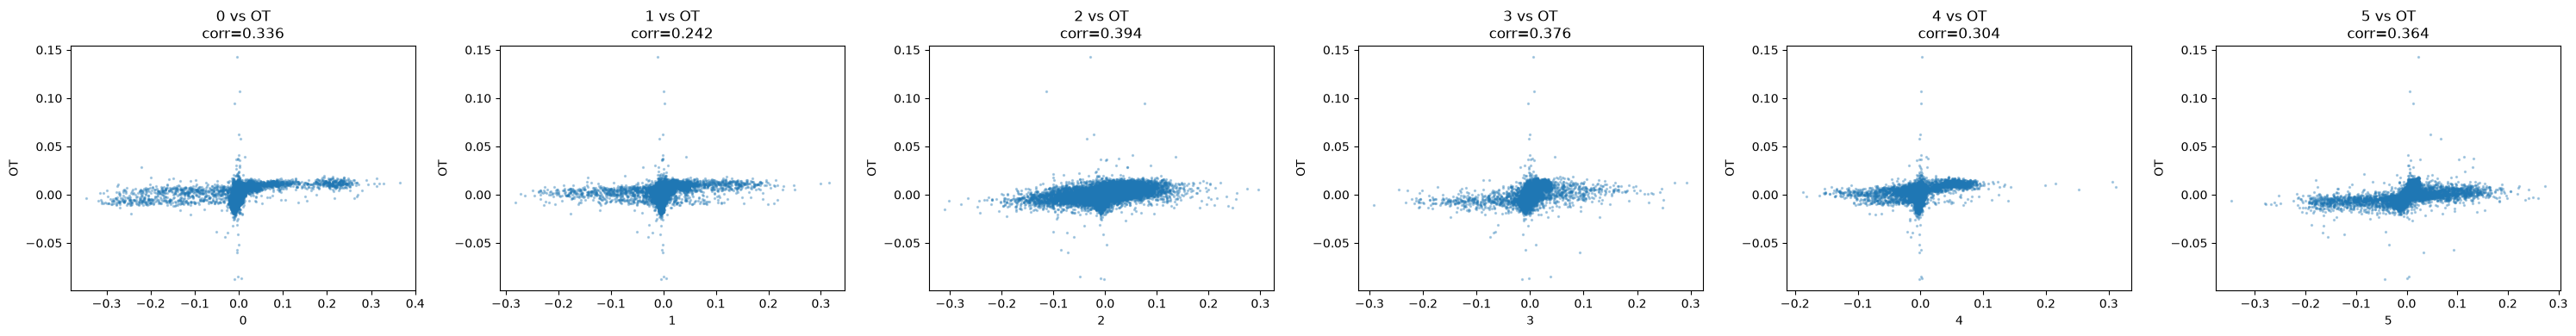

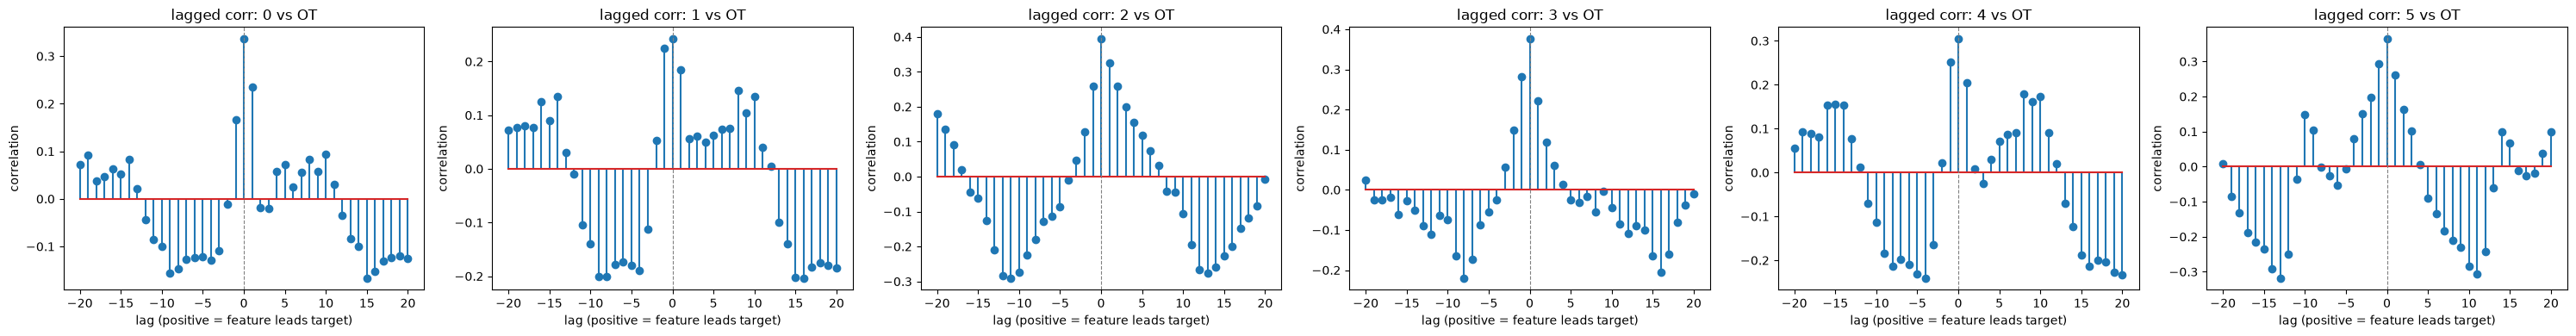

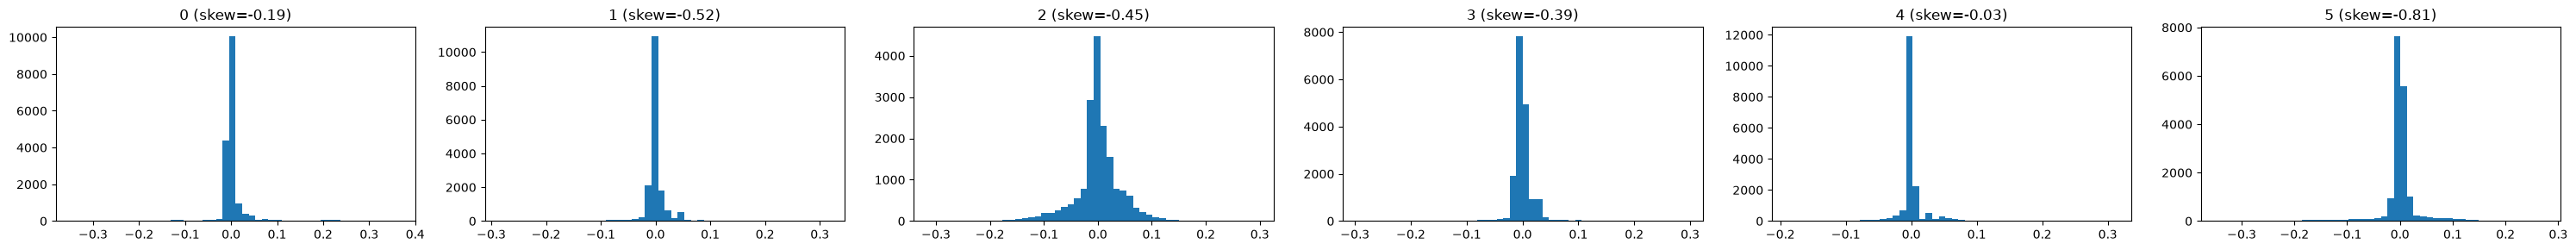

In [ ]:
considered_target_and_features = ["OT", "0", "1", "2", "3", "4", "5"]
traffic_df = RAW["traffic"].copy()
traffic_df["date"] = pd.to_datetime(traffic_df["date"])
traffic_df = traffic_df.set_index("date").sort_index()

# checking nearby sensors
traffic_df_diff = traffic_df[considered_target_and_features].diff().dropna()
traffic_corr_diff = feature_eda(
    traffic_df_diff, target_col=considered_target_and_features[0],
    feature_cols=considered_target_and_features[1:],
    name="traffic (differenced, sample sensors)",
)

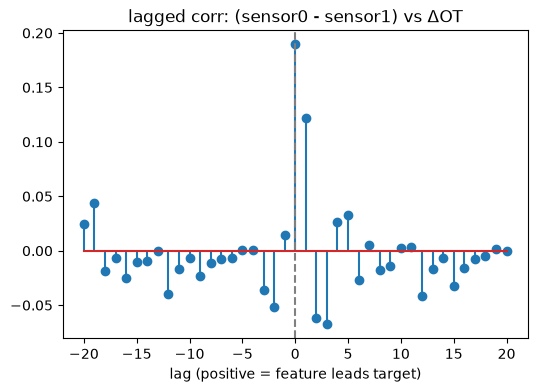

In [ ]:
traffic_df_diff = traffic_df[["OT", "0", "1"]].diff().dropna()

# difference BETWEEN two sensors
spatial_gradient = traffic_df_diff["0"] - traffic_df_diff["1"]

grad_corr = lagged_correlation(traffic_df_diff["OT"], spatial_gradient, max_lag=20)
lags = list(grad_corr.keys())
vals = list(grad_corr.values())

plt.figure(figsize=(6,4))
plt.stem(lags, vals)
plt.axvline(0, color="grey", linestyle="--")
plt.title("lagged corr: (sensor0 - sensor1) vs ΔOT")
plt.xlabel("lag (positive = feature leads target)")
plt.show()

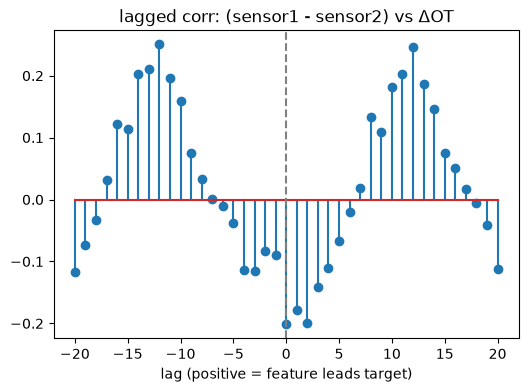

In [ ]:
traffic_df_diff = traffic_df[["OT", "1", "2"]].diff().dropna()

# difference BETWEEN two sensors
spatial_gradient = traffic_df_diff["1"] - traffic_df_diff["2"]

grad_corr = lagged_correlation(traffic_df_diff["OT"], spatial_gradient, max_lag=20)
lags = list(grad_corr.keys())
vals = list(grad_corr.values())

plt.figure(figsize=(6,4))
plt.stem(lags, vals)
plt.axvline(0, color="grey", linestyle="--")
plt.title("lagged corr: (sensor1 - sensor2) vs ΔOT")
plt.xlabel("lag (positive = feature leads target)")
plt.show()

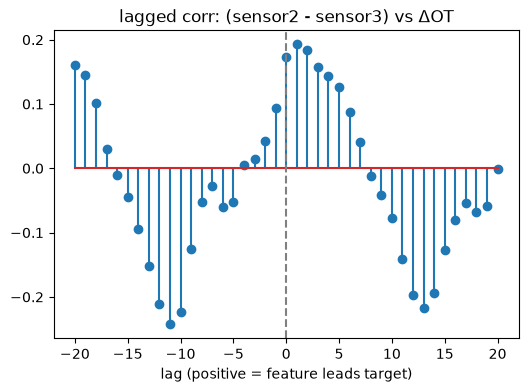

In [ ]:
traffic_df_diff = traffic_df[["OT", "2", "3"]].diff().dropna()

# difference BETWEEN two sensors
spatial_gradient = traffic_df_diff["2"] - traffic_df_diff["3"]

grad_corr = lagged_correlation(traffic_df_diff["OT"], spatial_gradient, max_lag=20)
lags = list(grad_corr.keys())
vals = list(grad_corr.values())

plt.figure(figsize=(6,4))
plt.stem(lags, vals)
plt.axvline(0, color="grey", linestyle="--")
plt.title("lagged corr: (sensor2 - sensor3) vs ΔOT")
plt.xlabel("lag (positive = feature leads target)")
plt.show()

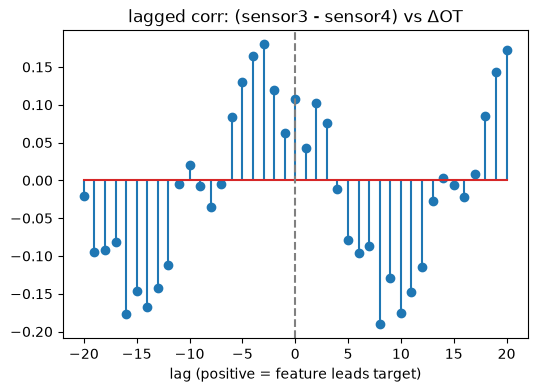

In [ ]:
traffic_df_diff = traffic_df[["OT", "3", "4"]].diff().dropna()

# difference BETWEEN two sensors
spatial_gradient = traffic_df_diff["3"] - traffic_df_diff["4"]

grad_corr = lagged_correlation(traffic_df_diff["OT"], spatial_gradient, max_lag=20)
lags = list(grad_corr.keys())
vals = list(grad_corr.values())

plt.figure(figsize=(6,4))
plt.stem(lags, vals)
plt.axvline(0, color="grey", linestyle="--")
plt.title("lagged corr: (sensor3 - sensor4) vs ΔOT")
plt.xlabel("lag (positive = feature leads target)")
plt.show()

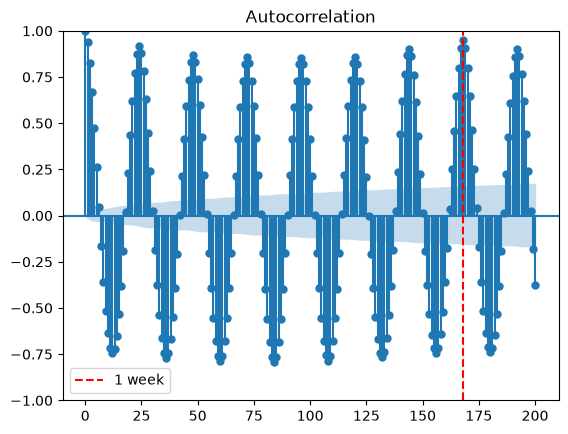

In [92]:
from statsmodels.graphics.tsaplots import plot_acf
plot_acf(SERIES["traffic"], lags=200)
plt.axvline(168, color="red", linestyle="--", label="1 week")
plt.legend()
plt.show()